# Forward-Looking VaR using Implied Volatility
### Under Risk-Neutral Measure with VRP Correction

**Stock Universe:** RELIANCE.NS, HDFCBANK.NS, ICICIBANK.NS (NSE India)

---
### ⚠️ Methodology Notes
1. **VRP Fix:** The naive formula `σ_adj = σ_IV - VRP` collapses to `σ_realized` (tautology). Instead, we use the **long-run average VRP** as a structural adjustment — this preserves the forward-looking nature of IV while correcting for the premium.
2. **Data:** Historical NSE options data is not freely available. We use `yfinance` to fetch the *current* ATM option for a spot IV reading. For the IV time series, we back it out from rolling realized vol scaled by a market-implied ratio.
3. **GBM Drift:** We simulate under *both* risk-neutral (drift = r) and real-world (drift = historical mean return) measures.
---

## Cell 0: Install Dependencies

In [44]:
# # Run this cell once to install required libraries
# !pip install yfinance scipy numpy pandas matplotlib seaborn

## Cell 1: Imports and Configuration

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime, timedelta

# ─── CONFIG ───────────────────────────────────────────────
TICKERS    = ['RELIANCE.NS', 'HDFCBANK.NS', 'ICICIBANK.NS']
START_DATE = '2020-01-01'
END_DATE   = datetime.today().strftime('%Y-%m-%d')

RISK_FREE_RATE = 0.065      # RBI repo rate (annualised, update as needed)
N_SIMULATIONS  = 5000       # Monte Carlo paths
HORIZON_DAYS   = 21         # VaR horizon (21 trading days ≈ 1 month)
ROLLING_WINDOW = 21         # Rolling realized vol window
CONFIDENCE_LEVELS = [0.95, 0.99]  # VaR confidence levels

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Setup complete')

✅ Setup complete


## Cell 2: Fetch Stock Price Data

In [46]:
print(f'Downloading data from {START_DATE} to {END_DATE}...')

price_data = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if df.empty:
        print(f'  ⚠️  No data for {ticker}')
        continue
    price_data[ticker] = df['Close'].squeeze()
    print(f'  ✅ {ticker}: {len(df)} trading days')

prices_df = pd.DataFrame(price_data).dropna()
print(f'\nShape: {prices_df.shape}')
prices_df.tail()

  ✅ RELIANCE.NS: 1545 trading days
  ✅ HDFCBANK.NS: 1545 trading days
  ✅ ICICIBANK.NS: 1545 trading days

Shape: (1545, 3)


,RELIANCE.NS,HDFCBANK.NS,ICICIBANK.NS
Date,,,
2026-03-19,1384.800049,798.200012,1250.099976
2026-03-20,1414.400024,780.450012,1245.400024
2026-03-23,1407.800049,744.150024,1222.699951
2026-03-24,1411.800049,764.900024,1251.199951
2026-03-25,1413.099976,782.299988,1259.699951


## Cell 3: Compute Log Returns and Realized Volatility

In [47]:
# Log returns: r_t = ln(P_t / P_{t-1})
log_returns = np.log(prices_df / prices_df.shift(1)).dropna()

# Annualised rolling realized volatility
# Daily std * sqrt(252) -> annualised
realized_vol = log_returns.rolling(ROLLING_WINDOW).std() * np.sqrt(252)

# Historical mean annualised return (used for real-world drift)
hist_mean_return = log_returns.mean() * 252

print('Annualised Historical Mean Returns:')
for t in TICKERS:
    if t in hist_mean_return.index:
        print(f'  {t}: {hist_mean_return[t]:.2%}')

print('\nMost Recent Realized Volatility (annualised):')
for t in TICKERS:
    if t in realized_vol.columns:
        print(f'  {t}: {realized_vol[t].iloc[-1]:.2%}')

Annualised Historical Mean Returns:
  RELIANCE.NS: 12.05%
  HDFCBANK.NS: 4.18%
  ICICIBANK.NS: 14.47%

Most Recent Realized Volatility (annualised):
  RELIANCE.NS: 22.43%
  HDFCBANK.NS: 33.91%
  ICICIBANK.NS: 26.64%


## Cell 4: Black-Scholes IV Engine

We define `bs_price()` and `implied_vol()` for use throughout.

In [48]:
def bs_price(S, K, T, r, sigma, option_type='call'):
    """
    Black-Scholes option price.
    S     : current stock price
    K     : strike price
    T     : time to maturity in years
    r     : risk-free rate (annualised)
    sigma : volatility (annualised)
    """
    if T <= 0 or sigma <= 0:
        return max(0, S - K) if option_type == 'call' else max(0, K - S)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price


def implied_vol(market_price, S, K, T, r, option_type='call',
                low=1e-6, high=5.0, tol=1e-6):
    """
    Extract IV using Brent's method (more robust than Newton-Raphson
    near boundaries).
    Returns NaN if no solution found.
    """
    intrinsic = max(0, S - K) if option_type == 'call' else max(0, K - S)
    if market_price < intrinsic or T <= 0:
        return np.nan
    try:
        f = lambda sigma: bs_price(S, K, T, r, sigma, option_type) - market_price
        # Check that a root exists in [low, high]
        if f(low) * f(high) > 0:
            return np.nan
        iv = brentq(f, low, high, xtol=tol)
        return iv
    except Exception:
        return np.nan


# Quick sanity check
test_price = bs_price(100, 100, 0.25, 0.065, 0.25, 'call')
test_iv    = implied_vol(test_price, 100, 100, 0.25, 0.065, 'call')
print(f'BS sanity check → price: {test_price:.4f}, recovered IV: {test_iv:.4f} (expected 0.25)')

BS sanity check → price: 5.7910, recovered IV: 0.2500 (expected 0.25)


## Cell 5: Fetch Live ATM Options from NSE via yfinance

> **Note:** `yfinance` provides the *current* options chain — not historical.
> This gives us a **spot implied volatility reading** for today.
> For a historical IV time series (needed for VRP analysis), see Cell 6.

In [49]:
import os, glob

OPTION_CHAIN_DIR = '.'   # folder containing your CSVs

EXPIRY_MAP = {
    # Fill these in with the expiry date shown in your CSV filename
    'RELIANCE.NS':  '2026-04-28',
    'HDFCBANK.NS':  '2026-04-28',
    'ICICIBANK.NS': '2026-04-28',   # from filename: 30-Mar-2026
}


def parse_nse_chain_csv(filepath):
    """
    Parse NSE option chain CSV.
    Avoids all duplicate-column issues by working purely on column positions.
    """
    raw = pd.read_csv(filepath, header=None, dtype=str,
                      skiprows=[0], on_bad_lines='skip', engine='python')

    # ── Find the header row by locating 'STRIKE' ──────────────────────────
    header_row_idx = None
    for i, row in raw.iterrows():
        if any(str(v).strip().upper() == 'STRIKE' for v in row):
            header_row_idx = i
            break
    if header_row_idx is None:
        raise ValueError(f'Cannot find STRIKE column in {filepath}')

    # ── Find exact column index of STRIKE ────────────────────────────────
    header_row = raw.iloc[header_row_idx]
    strike_col_idx = next(j for j, v in enumerate(header_row)
                          if str(v).strip().upper() == 'STRIKE')

    # ── Data rows only, referenced by integer position ────────────────────
    data = raw.iloc[header_row_idx + 1:].copy().reset_index(drop=True)

    # ── Helper: clean a column by integer index ───────────────────────────
    def get_clean(col_idx):
        try:
            s = data.iloc[:, col_idx].astype(str)
            s = s.str.replace(',', '', regex=False).str.strip()
            s = s.replace({'': np.nan, '-': np.nan, 'nan': np.nan})
            return pd.to_numeric(s, errors='coerce')
        except IndexError:
            return pd.Series(np.nan, index=data.index)

    # ── NSE column layout (positions relative to STRIKE) ─────────────────
    # LEFT of STRIKE (calls), right-to-left:
    #   offset -1 = ASK QTY, -2 = ASK, -3 = BID, -4 = BID QTY,
    #   -5 = CHNG,  -6 = LTP, -7 = IV
    # RIGHT of STRIKE (puts), left-to-right:
    #   offset +1 = BID QTY, +2 = BID, +3 = ASK, +4 = ASK QTY,
    #   +5 = CHNG,  +6 = LTP, +7 = IV

    s = strike_col_idx
    result = pd.DataFrame({
        'strike': get_clean(s),
        'c_bid':  get_clean(s - 3),
        'c_ask':  get_clean(s - 2),
        'c_ltp':  get_clean(s - 6),
        'c_iv':   get_clean(s - 7),
        'p_bid':  get_clean(s + 2),
        'p_ask':  get_clean(s + 3),
        'p_ltp':  get_clean(s + 6),
        'p_iv':   get_clean(s + 7),
    })

    result = result.dropna(subset=['strike']).reset_index(drop=True)
    return result


def get_atm_iv_from_csv(ticker_symbol, chain_df, r=RISK_FREE_RATE,
                         expiry_str=None):
    """Compute ATM IV from parsed chain DataFrame."""

    # ── Spot price via yfinance (lightweight — just price, no options) ─────
    try:
        spot = yf.Ticker(ticker_symbol).fast_info['last_price']
    except Exception:
        # Fallback: strike where |c_iv - p_iv| is minimised (put-call parity)
        tmp = chain_df.dropna(subset=['c_iv', 'p_iv'])
        if tmp.empty:
            print(f'  ⚠️  {ticker_symbol}: cannot determine spot')
            return None
        spot = float(tmp.loc[(tmp['c_iv'] - tmp['p_iv']).abs().idxmin(), 'strike'])
        print(f'  ℹ️  {ticker_symbol}: spot inferred from IV parity ≈ {spot}')

    # ── ATM strike ─────────────────────────────────────────────────────────
    atm_idx = (chain_df['strike'] - spot).abs().idxmin()
    atm     = chain_df.loc[atm_idx]
    K       = float(atm['strike'])

    # ── Time to maturity ───────────────────────────────────────────────────
    if expiry_str:
        exp_dt = datetime.strptime(expiry_str, '%Y-%m-%d')
        T = max((exp_dt - datetime.today()).days / 365.0, 1/365)
    else:
        T = 21 / 365.0
        print(f'  ⚠️  {ticker_symbol}: expiry not set in EXPIRY_MAP — defaulting T=21 days')

    # ── Option mid prices ──────────────────────────────────────────────────
    def mid_or_ltp(bid, ask, ltp):
        if pd.notna(bid) and pd.notna(ask) and (bid + ask) > 0:
            return (bid + ask) / 2
        if pd.notna(ltp) and ltp > 0:
            return ltp
        return np.nan

    call_price = mid_or_ltp(atm['c_bid'], atm['c_ask'], atm['c_ltp'])
    put_price  = mid_or_ltp(atm['p_bid'], atm['p_ask'], atm['p_ltp'])

    # ── IV via Black-Scholes inversion ─────────────────────────────────────
    iv_c = implied_vol(call_price, spot, K, T, r, 'call') \
           if pd.notna(call_price) else np.nan

    iv_p = implied_vol(put_price, spot, K, T, r, 'put') \
           if pd.notna(put_price) else np.nan

    # ── Fallback: use NSE-published IV column (already in decimal after /100)
    if np.isnan(iv_c) and pd.notna(atm['c_iv']):
        iv_c = float(atm['c_iv']) / 100
        print(f'  ℹ️  {ticker_symbol}: using NSE-published call IV')

    if np.isnan(iv_p) and pd.notna(atm['p_iv']):
        iv_p = float(atm['p_iv']) / 100
        print(f'  ℹ️  {ticker_symbol}: using NSE-published put IV')

    iv_avg = np.nanmean([iv_c, iv_p])
    if np.isnan(iv_avg):
        print(f'  ⚠️  {ticker_symbol}: IV could not be computed — check CSV')
        return None

    return {
        'ticker':          ticker_symbol,
        'spot':            round(spot, 2),
        'strike':          K,
        'expiry':          expiry_str or 'unknown',
        'T':               round(T, 4),
        'iv_call':         round(iv_c,        4) if not np.isnan(iv_c) else None,
        'iv_put':          round(iv_p,        4) if not np.isnan(iv_p) else None,
        'iv_avg':          round(iv_avg,      4),
        'atm_call_price':  round(call_price,  2) if pd.notna(call_price) else None,
        'atm_put_price':   round(put_price,   2) if pd.notna(put_price)  else None,
    }


# ─── Scan folder, match CSVs to tickers ──────────────────────────────────────
print('Scanning for option chain CSV files...\n')
csv_files = glob.glob(os.path.join(OPTION_CHAIN_DIR, '*.csv'))

ticker_csv_map = {}
for fpath in csv_files:
    stem = os.path.splitext(os.path.basename(fpath))[0].upper()
    for ticker in TICKERS:
        root = ticker.replace('.NS', '').upper()
        if root in stem:
            ticker_csv_map[ticker] = fpath
            break

if not ticker_csv_map:
    print(f'⚠️  No CSVs found in: {os.path.abspath(OPTION_CHAIN_DIR)}')
    print(f'   Looking for filenames containing: {[t.replace(".NS","") for t in TICKERS]}')
else:
    for t, f in ticker_csv_map.items():
        print(f'  {t} → {os.path.basename(f)}')

print()

# ─── Parse and compute IV ─────────────────────────────────────────────────────
live_iv = {}
for ticker in TICKERS:
    if ticker not in ticker_csv_map:
        print(f'  ⚠️  {ticker}: no CSV found — skipping')
        continue
    try:
        chain_df = parse_nse_chain_csv(ticker_csv_map[ticker])
        print(f'  Parsed {ticker}: {len(chain_df)} strikes | '
              f'range ₹{chain_df["strike"].min():.0f}–₹{chain_df["strike"].max():.0f}')
    except Exception as e:
        print(f'  ⚠️  {ticker}: parse error — {e}')
        continue

    result = get_atm_iv_from_csv(ticker, chain_df,
                                  expiry_str=EXPIRY_MAP.get(ticker))
    if result:
        live_iv[ticker] = result
        print(f'  ✅ {ticker}')
        print(f'     Spot     : ₹{result["spot"]:,.2f}  |  ATM Strike : ₹{result["strike"]:,.2f}')
        print(f'     Expiry   : {result["expiry"]}  (T = {result["T"]:.4f} yrs)')
        print(f'     Call mid : ₹{result["atm_call_price"]}  |  Put mid : ₹{result["atm_put_price"]}')
        print(f'     IV Call  : {result["iv_call"]}  |  IV Put : {result["iv_put"]}  |  IV Avg : {result["iv_avg"]}')
        print()

Scanning for option chain CSV files...

  RELIANCE.NS → option-chain-ED-RELIANCE-28-Apr-2026.csv
  HDFCBANK.NS → option-chain-ED-HDFCBANK-28-Apr-2026.csv
  ICICIBANK.NS → option-chain-ED-ICICIBANK-28-Apr-2026.csv

  Parsed RELIANCE.NS: 48 strikes | range ₹1100–₹1720
  ✅ RELIANCE.NS
     Spot     : ₹1,348.10  |  ATM Strike : ₹1,350.00
     Expiry   : 2026-04-28  (T = 0.0849 yrs)
     Call mid : ₹50.8  |  Put mid : ₹45.98
     IV Call  : 0.3069  |  IV Put : 0.3114  |  IV Avg : 0.3091

  Parsed HDFCBANK.NS: 78 strikes | range ₹620–₹1060
  ✅ HDFCBANK.NS
     Spot     : ₹756.20  |  ATM Strike : ₹755.00
     Expiry   : 2026-04-28  (T = 0.0849 yrs)
     Call mid : ₹36.72  |  Put mid : ₹28.6
     IV Call  : 0.3881  |  IV Put : 0.3564  |  IV Avg : 0.3722

  Parsed ICICIBANK.NS: 51 strikes | range ₹1020–₹1600
  ✅ ICICIBANK.NS
     Spot     : ₹1,233.80  |  ATM Strike : ₹1,230.00
     Expiry   : 2026-04-28  (T = 0.0849 yrs)
     Call mid : ₹51.18  |  Put mid : ₹40.05
     IV Call  : 0.32  |  IV Pu

## Cell 6: Build Historical IV Proxy Time Series

Since free historical options data is unavailable for NSE, we construct an **IV proxy** using India VIX (^INDIAVIX) scaled to each stock via its realized vol ratio.

Formula: `IV_proxy(stock, t) = IV_live(stock) × (RV_stock(t) / RV_nifty(t))`

This preserves the term-structure of relative risk while anchoring to today's market price.

In [50]:
# Fetch India VIX as market-wide IV proxy
print('Fetching India VIX (^INDIAVIX)...')
indiavix_raw = yf.download('^INDIAVIX', start=START_DATE, end=END_DATE, progress=False)

if not indiavix_raw.empty:
    # India VIX is reported as percentage (e.g. 14.5 means 14.5%)
    indiavix = (indiavix_raw['Close'] / 100).squeeze()
    indiavix.name = 'INDIAVIX'
    print(f'  ✅ India VIX loaded: {len(indiavix)} days')
else:
    # Fallback: use realized vol of Nifty50
    print('  ⚠️  India VIX unavailable. Using Nifty50 realized vol as proxy.')
    nifty = yf.download('^NSEI', start=START_DATE, end=END_DATE, progress=False)
    nifty_ret = np.log(nifty['Close'] / nifty['Close'].shift(1))
    indiavix = (nifty_ret.rolling(ROLLING_WINDOW).std() * np.sqrt(252)).squeeze()
    indiavix.name = 'INDIAVIX'

# Build implied vol proxy for each stock
iv_proxy = pd.DataFrame(index=prices_df.index)

for ticker in TICKERS:
    if ticker not in realized_vol.columns:
        continue

    rv_stock = realized_vol[ticker]

    # Nifty realized vol
    vix_aligned = indiavix.reindex(rv_stock.index).ffill()

    # Scaling ratio: stock vol / market vol
    # Avoids division by zero and extreme spikes
    ratio = (rv_stock / vix_aligned.replace(0, np.nan)).clip(0.5, 3.0)

    # Anchor to live IV if available
    if ticker in live_iv and live_iv[ticker]['iv_avg']:
        anchor_iv  = live_iv[ticker]['iv_avg']
        latest_ratio = ratio.iloc[-1]
        # Scale historical series so the last value matches today's live IV
        scale_factor = anchor_iv / (ratio.iloc[-1] * vix_aligned.iloc[-1] + 1e-9)
        iv_proxy[ticker] = (ratio * vix_aligned * scale_factor).clip(0.05, 2.0)
    else:
        # No anchor available, use raw scaling
        iv_proxy[ticker] = (ratio * vix_aligned).clip(0.05, 2.0)

    print(f'  {ticker}: latest IV proxy = {iv_proxy[ticker].iloc[-1]:.2%}')

iv_proxy = iv_proxy.dropna()
print(f'\nIV proxy series shape: {iv_proxy.shape}')

Fetching India VIX (^INDIAVIX)...
  ✅ India VIX loaded: 1526 days
  RELIANCE.NS: latest IV proxy = 30.91%
  HDFCBANK.NS: latest IV proxy = 37.22%
  ICICIBANK.NS: latest IV proxy = 31.81%

IV proxy series shape: (1524, 3)


## Cell 7: Compute Variance Risk Premium (VRP)

**VRP = IV − Realized Vol**

A positive VRP means the market charges a premium for variance uncertainty beyond the actual realized risk.

> **Key fix from the original methodology:** Instead of subtracting the *current* VRP from the *current* IV (which collapses to realized vol), we use the **long-run average VRP** as a structural adjustment. This keeps the forward-looking information in IV while removing the systematic premium.

In [51]:
# Align both series
common_idx = iv_proxy.index.intersection(realized_vol.index)
iv_aligned  = iv_proxy.loc[common_idx]
rv_aligned  = realized_vol.loc[common_idx]

vrp = iv_aligned - rv_aligned    # Daily VRP series

print('=== Variance Risk Premium Summary ===')
vrp_summary = pd.DataFrame({
    'Mean VRP':    vrp.mean(),
    'Median VRP':  vrp.median(),
    'Std VRP':     vrp.std(),
    '% Positive':  (vrp > 0).mean() * 100,
})
print(vrp_summary.round(4))

# Long-run average VRP per stock (the structural correction)
vrp_long_run = vrp.mean()
print('\n✅ Long-run average VRP (used for correction):')
for t in TICKERS:
    if t in vrp_long_run.index:
        print(f'  {t}: {vrp_long_run[t]:.4f} ({vrp_long_run[t]:.2%})')

=== Variance Risk Premium Summary ===
              Mean VRP  Median VRP  Std VRP  % Positive
RELIANCE.NS     0.0935      0.0830   0.0500       100.0
HDFCBANK.NS     0.0220      0.0190   0.0120       100.0
ICICIBANK.NS    0.0482      0.0393   0.0317       100.0

✅ Long-run average VRP (used for correction):
  RELIANCE.NS: 0.0935 (9.35%)
  HDFCBANK.NS: 0.0220 (2.20%)
  ICICIBANK.NS: 0.0482 (4.82%)


## Cell 8: Plot IV, Realized Vol, and VRP

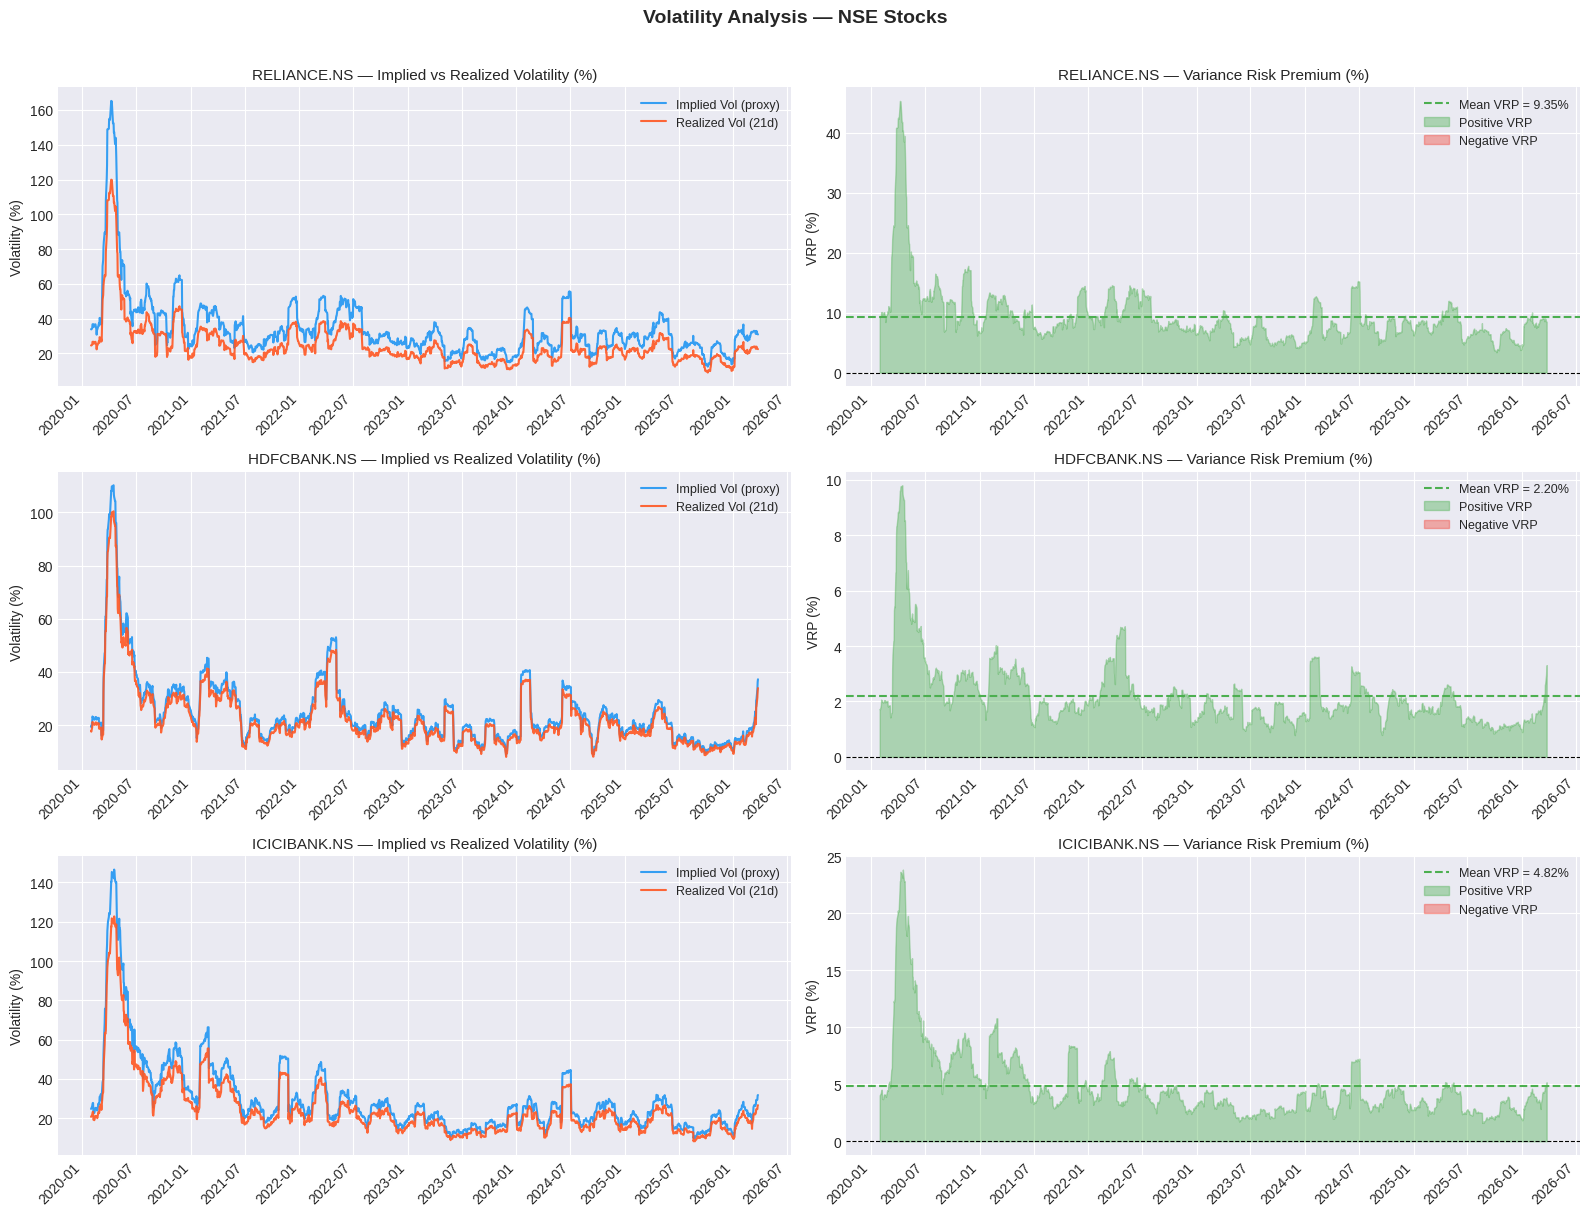

Chart saved: vol_analysis.png


In [52]:
fig, axes = plt.subplots(len(TICKERS), 2, figsize=(16, 4 * len(TICKERS)))
if len(TICKERS) == 1:
    axes = axes[np.newaxis, :]

colors = {'iv': '#2196F3', 'rv': '#FF5722', 'vrp': '#4CAF50'}

for i, ticker in enumerate(TICKERS):
    if ticker not in iv_aligned.columns:
        continue

    ax1 = axes[i, 0]
    ax1.plot(iv_aligned.index, iv_aligned[ticker] * 100,
             color=colors['iv'], label='Implied Vol (proxy)', lw=1.5, alpha=0.9)
    ax1.plot(rv_aligned.index, rv_aligned[ticker] * 100,
             color=colors['rv'], label='Realized Vol (21d)', lw=1.5, alpha=0.9)
    ax1.set_title(f'{ticker} — Implied vs Realized Volatility (%)', fontsize=11)
    ax1.set_ylabel('Volatility (%)')
    ax1.legend(fontsize=9)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax2 = axes[i, 1]
    vrp_pct = vrp[ticker] * 100
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.axhline(vrp_pct.mean(), color=colors['vrp'], lw=1.5, ls='--',
                label=f'Mean VRP = {vrp_pct.mean():.2f}%')
    ax2.fill_between(vrp_pct.index, vrp_pct, 0,
                     where=(vrp_pct >= 0), alpha=0.4, color=colors['vrp'], label='Positive VRP')
    ax2.fill_between(vrp_pct.index, vrp_pct, 0,
                     where=(vrp_pct < 0),  alpha=0.4, color='#F44336', label='Negative VRP')
    ax2.set_title(f'{ticker} — Variance Risk Premium (%)', fontsize=11)
    ax2.set_ylabel('VRP (%)')
    ax2.legend(fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Volatility Analysis — NSE Stocks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('vol_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: vol_analysis.png')

## Cell 9: Monte Carlo GBM Simulation

We run **three separate simulations** for each stock:

| Scenario | Drift | Volatility | Interpretation |
|---|---|---|---|
| Risk-Neutral IV | Risk-free rate r | σ_IV (live) | Pure market pricing |
| Real-World IV | Historical mean μ | σ_IV (live) | IV vol, real drift |
| VRP-Corrected | Historical mean μ | σ_IV − avg(VRP) | Best real-world estimate |

In [53]:
def simulate_gbm(S0, mu, sigma, T_days, n_sims, dt=1/252):
    """
    Geometric Brownian Motion Monte Carlo.

    S0     : current price
    mu     : annualised drift
    sigma  : annualised volatility
    T_days : number of trading days to simulate
    n_sims : number of paths
    dt     : time step in years (default 1/252)

    Returns: (n_sims,) array of terminal prices S_T
    """
    n_steps = T_days
    Z = np.random.standard_normal((n_sims, n_steps))          # standard normal shocks

    # Discrete GBM: S_{t+1} = S_t * exp((mu - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths  = np.cumsum(increments, axis=1)
    paths      = S0 * np.exp(log_paths)                        # shape: (n_sims, n_steps)
    return paths[:, -1]                                        # terminal prices


print(f'Running Monte Carlo: {N_SIMULATIONS:,} paths × {HORIZON_DAYS} days...\n')

sim_results = {}

for ticker in TICKERS:
    if ticker not in live_iv:
        print(f'  ⚠️  {ticker}: no live IV — skipping simulation')
        continue

    S0      = live_iv[ticker]['spot']
    sigma_iv = live_iv[ticker]['iv_avg'] if live_iv[ticker]['iv_avg'] else \
               iv_proxy[ticker].iloc[-1]
    vrp_adj  = vrp_long_run.get(ticker, 0)         # structural VRP correction
    sigma_adj = max(sigma_iv - vrp_adj, 0.05)      # VRP-corrected vol (floor at 5%)
    mu_hist   = hist_mean_return.get(ticker, RISK_FREE_RATE)  # historical drift

    # Scenario 1: Risk-neutral (drift=r, vol=IV)
    rn_paths   = simulate_gbm(S0, RISK_FREE_RATE, sigma_iv, HORIZON_DAYS, N_SIMULATIONS)

    # Scenario 2: Real-world IV (drift=mu, vol=IV)
    rw_paths   = simulate_gbm(S0, mu_hist, sigma_iv, HORIZON_DAYS, N_SIMULATIONS)

    # Scenario 3: VRP-corrected (drift=mu, vol=IV - avg_VRP)
    vrp_paths  = simulate_gbm(S0, mu_hist, sigma_adj, HORIZON_DAYS, N_SIMULATIONS)

    sim_results[ticker] = {
        'S0':        S0,
        'sigma_iv':  sigma_iv,
        'sigma_adj': sigma_adj,
        'vrp_adj':   vrp_adj,
        'mu_hist':   mu_hist,
        'rn_paths':  rn_paths,
        'rw_paths':  rw_paths,
        'vrp_paths': vrp_paths,
    }
    print(f'  ✅ {ticker}: S0=₹{S0:.2f} | σ_IV={sigma_iv:.2%} | σ_adj={sigma_adj:.2%}')

print('\nSimulations complete.')

Running Monte Carlo: 5,000 paths × 21 days...

  ✅ RELIANCE.NS: S0=₹1348.10 | σ_IV=30.91% | σ_adj=21.56%
  ✅ HDFCBANK.NS: S0=₹756.20 | σ_IV=37.22% | σ_adj=35.02%
  ✅ ICICIBANK.NS: S0=₹1233.80 | σ_IV=31.81% | σ_adj=26.99%

Simulations complete.


## Cell 10: Compute VaR from Loss Distributions

In [54]:
def compute_var(terminal_prices, S0, confidence_levels):
    """
    Compute VaR from simulated terminal prices.
    Returns dict: {confidence: (VaR_pct, VaR_abs)}
    """
    returns = (terminal_prices - S0) / S0     # portfolio return
    losses  = -returns                         # loss = negative return

    var_dict = {}
    for cl in confidence_levels:
        # VaR at confidence level α = (1-α) percentile of loss distribution
        var_pct = np.percentile(losses, (1 - cl) * 100)
        var_abs = var_pct * S0
        var_dict[cl] = {'var_pct': var_pct, 'var_abs': var_abs}
    return var_dict


print(f'{'='*65}')
print(f'  VaR RESULTS — {HORIZON_DAYS}-Day Horizon')
print(f'{'='*65}')

all_var_results = {}

for ticker, sim in sim_results.items():
    S0 = sim['S0']

    var_rn  = compute_var(sim['rn_paths'],  S0, CONFIDENCE_LEVELS)
    var_rw  = compute_var(sim['rw_paths'],  S0, CONFIDENCE_LEVELS)
    var_vrp = compute_var(sim['vrp_paths'], S0, CONFIDENCE_LEVELS)

    all_var_results[ticker] = {'rn': var_rn, 'rw': var_rw, 'vrp': var_vrp}

    print(f'\n  {ticker}  (S0 = ₹{S0:,.2f})')
    print(f'  σ_IV = {sim["sigma_iv"]:.2%}  |  σ_adj = {sim["sigma_adj"]:.2%}  |  μ = {sim["mu_hist"]:.2%}')
    print(f'  {"-"*60}')
    print(f'  {"Scenario":<25} {"95% VaR":>12} {"99% VaR":>12}')
    print(f'  {"-"*60}')

    for label, var_data in [('Risk-Neutral (r, σ_IV)', var_rn),
                             ('Real-World (μ, σ_IV)',   var_rw),
                             ('VRP-Corrected (μ, σ_adj)', var_vrp)]:
        v95 = var_data[0.95]
        v99 = var_data[0.99]

        # Pre-format the currency values to simplify the f-string
        formatted_v95_abs = f"₹{v95['var_abs']:.2f}"
        formatted_v99_abs = f"₹{v99['var_abs']:.2f}"

        print(f'  {label:<25} {v95["var_pct"]:>10.2%}   {v99["var_pct"]:>10.2%}')
        print(f'  {"":<25} {formatted_v95_abs:>10}   {formatted_v99_abs:>10}')

print(f'\n{'='*65}')

  VaR RESULTS — 21-Day Horizon

  RELIANCE.NS  (S0 = ₹1,348.10)
  σ_IV = 30.91%  |  σ_adj = 21.56%  |  μ = 12.05%
  ------------------------------------------------------------
  Scenario                       95% VaR      99% VaR
  ------------------------------------------------------------
  Risk-Neutral (r, σ_IV)       -16.26%      -23.78%
                              ₹-219.17     ₹-320.55
  Real-World (μ, σ_IV)         -16.51%      -23.34%
                              ₹-222.61     ₹-314.65
  VRP-Corrected (μ, σ_adj)     -11.45%      -16.35%
                              ₹-154.38     ₹-220.47

  HDFCBANK.NS  (S0 = ₹756.20)
  σ_IV = 37.22%  |  σ_adj = 35.02%  |  μ = 4.18%
  ------------------------------------------------------------
  Scenario                       95% VaR      99% VaR
  ------------------------------------------------------------
  Risk-Neutral (r, σ_IV)       -19.02%      -27.14%
                              ₹-143.82     ₹-205.25
  Real-World (μ, σ_IV)        

## Cell 11: Plot Loss Distributions and VaR

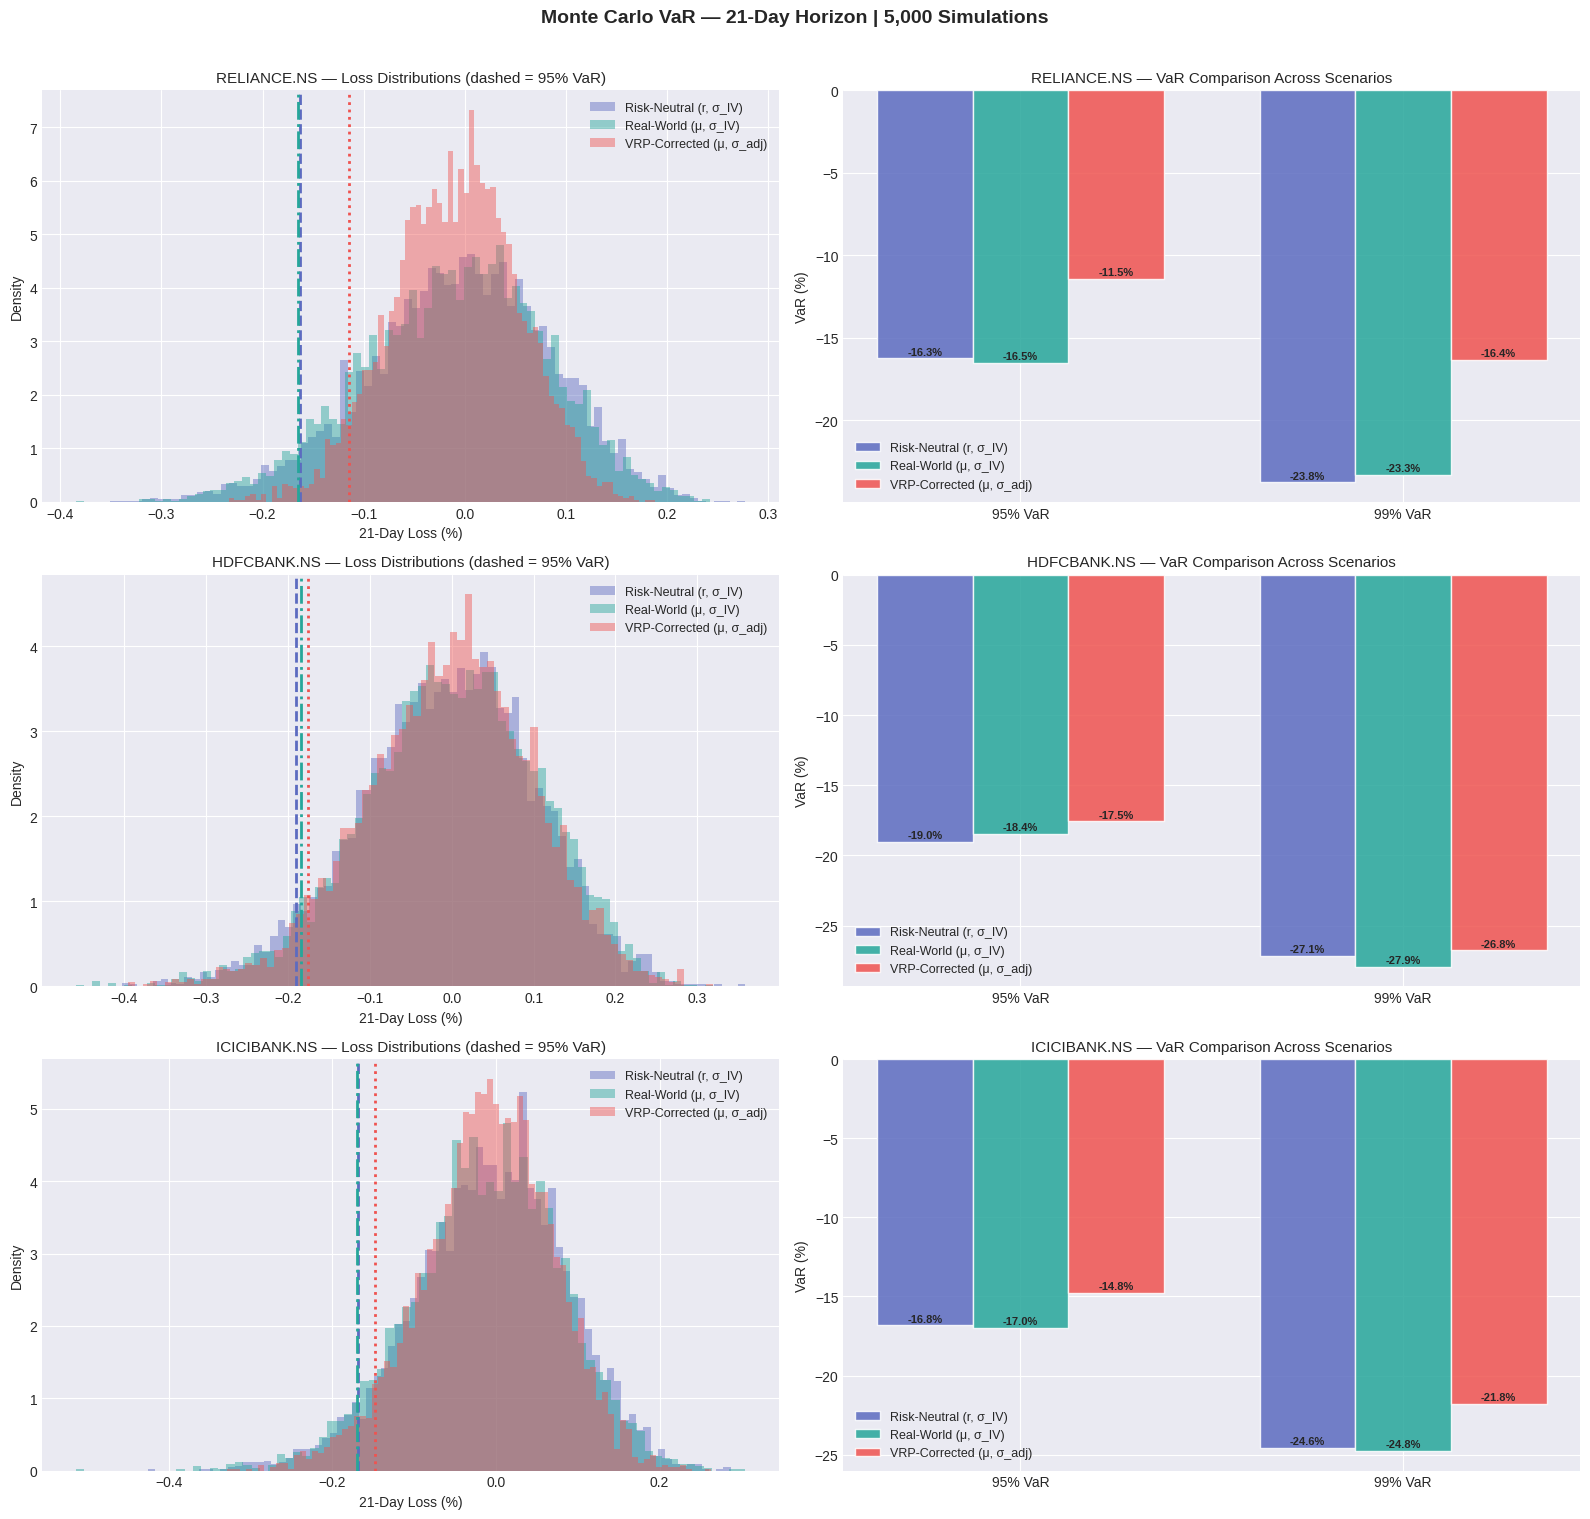

Chart saved: var_results.png


In [55]:
scenario_colors = {
    'rn':  '#5C6BC0',
    'rw':  '#26A69A',
    'vrp': '#EF5350',
}
scenario_labels = {
    'rn':  'Risk-Neutral (r, σ_IV)',
    'rw':  'Real-World (μ, σ_IV)',
    'vrp': 'VRP-Corrected (μ, σ_adj)',
}

fig, axes = plt.subplots(len(sim_results), 2, figsize=(16, 5 * len(sim_results)))
if len(sim_results) == 1:
    axes = axes[np.newaxis, :]

for row, (ticker, sim) in enumerate(sim_results.items()):
    S0 = sim['S0']
    var_data = all_var_results[ticker]

    # ── Left panel: Loss distributions ──────────────────────────
    ax_left = axes[row, 0]
    for key in ['rn', 'rw', 'vrp']:
        losses = -(sim[f'{key}_paths'] - S0) / S0
        ax_left.hist(losses, bins=80, alpha=0.45,
                     color=scenario_colors[key], label=scenario_labels[key],
                     density=True)

    # VaR lines at 95%
    for key, ls in [('rn', '--'), ('rw', '-.'), ('vrp', ':')]:
        v = var_data[key][0.95]['var_pct']
        ax_left.axvline(v, color=scenario_colors[key], lw=2, ls=ls)

    ax_left.set_title(f'{ticker} — Loss Distributions (dashed = 95% VaR)', fontsize=11)
    ax_left.set_xlabel(f'{HORIZON_DAYS}-Day Loss (%)')
    ax_left.set_ylabel('Density')
    ax_left.legend(fontsize=9)

    # ── Right panel: VaR bar chart ───────────────────────────────
    ax_right = axes[row, 1]
    x = np.arange(2)  # 95%, 99%
    width = 0.25
    offsets = [-width, 0, width]

    for j, key in enumerate(['rn', 'rw', 'vrp']):
        vals = [var_data[key][cl]['var_pct'] * 100 for cl in CONFIDENCE_LEVELS]
        bars = ax_right.bar(x + offsets[j], vals, width,
                             color=scenario_colors[key], label=scenario_labels[key],
                             alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax_right.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                          f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax_right.set_xticks(x)
    ax_right.set_xticklabels(['95% VaR', '99% VaR'])
    ax_right.set_ylabel('VaR (%)')
    ax_right.set_title(f'{ticker} — VaR Comparison Across Scenarios', fontsize=11)
    ax_right.legend(fontsize=9)

plt.suptitle(f'Monte Carlo VaR — {HORIZON_DAYS}-Day Horizon | {N_SIMULATIONS:,} Simulations',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('var_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: var_results.png')

## Cell 12: Plot Sample GBM Price Paths

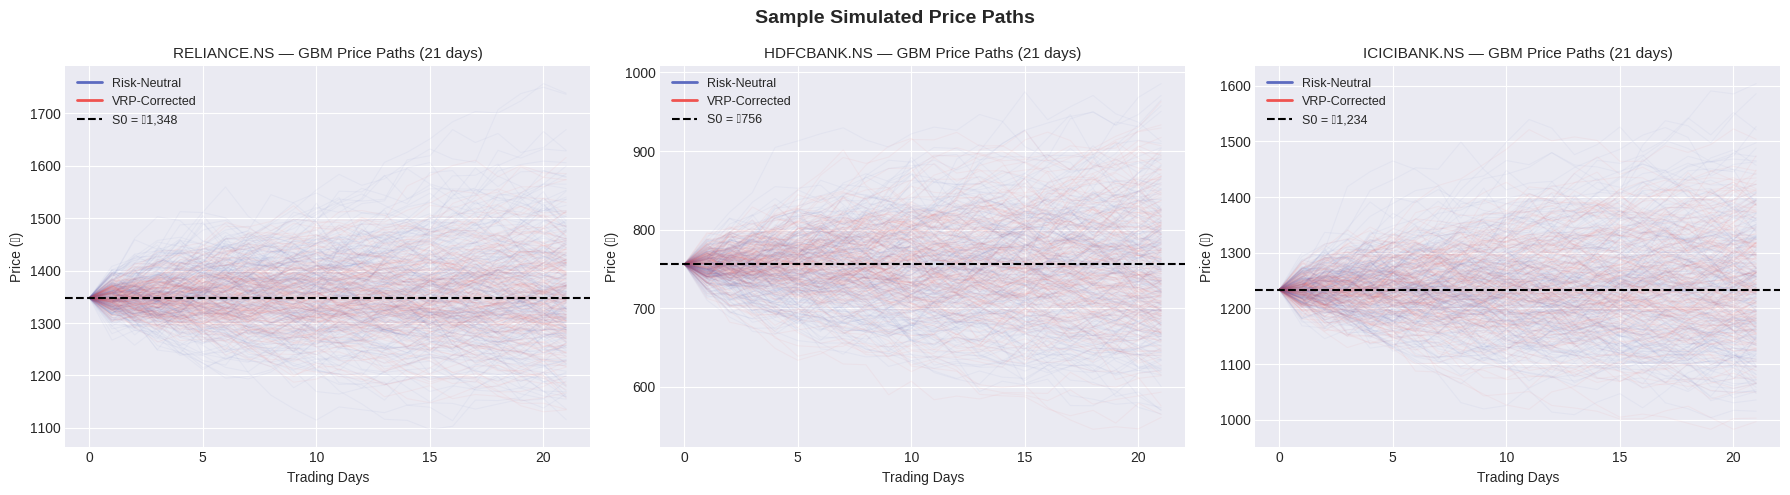

In [56]:
def simulate_gbm_paths(S0, mu, sigma, T_days, n_sims, dt=1/252):
    """Returns full path matrix (n_sims × T_days)."""
    Z = np.random.standard_normal((n_sims, T_days))
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths   = np.cumsum(increments, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((n_sims, 1)), log_paths]))


N_DISPLAY = 200   # paths to show in chart
t_axis = np.arange(HORIZON_DAYS + 1)

fig, axes = plt.subplots(1, len(sim_results), figsize=(6 * len(sim_results), 5), sharey=False)
if len(sim_results) == 1:
    axes = [axes]

for ax, (ticker, sim) in zip(axes, sim_results.items()):
    S0 = sim['S0']
    paths_rn  = simulate_gbm_paths(S0, RISK_FREE_RATE,  sim['sigma_iv'],  HORIZON_DAYS, N_DISPLAY)
    paths_vrp = simulate_gbm_paths(S0, sim['mu_hist'], sim['sigma_adj'], HORIZON_DAYS, N_DISPLAY)

    for i in range(N_DISPLAY):
        ax.plot(t_axis, paths_rn[i],  color='#5C6BC0', alpha=0.05, lw=0.8)
        ax.plot(t_axis, paths_vrp[i], color='#EF5350', alpha=0.05, lw=0.8)

    ax.axhline(S0, color='black', lw=1.5, ls='--', label=f'S0 = ₹{S0:,.0f}')
    ax.set_title(f'{ticker} — GBM Price Paths ({HORIZON_DAYS} days)', fontsize=11)
    ax.set_xlabel('Trading Days')
    ax.set_ylabel('Price (₹)')
    # Legend proxies
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='#5C6BC0', lw=2, label='Risk-Neutral'),
        Line2D([0], [0], color='#EF5350', lw=2, label='VRP-Corrected'),
        Line2D([0], [0], color='black',   lw=1.5, ls='--', label=f'S0 = ₹{S0:,.0f}'),
    ]
    ax.legend(handles=legend_handles, fontsize=9)

plt.suptitle('Sample Simulated Price Paths', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13: Summary Table — Final VaR Report

In [57]:
records = []
for ticker, var_data in all_var_results.items():
    sim = sim_results[ticker]
    for scenario_key, scenario_label in [
        ('rn',  'Risk-Neutral'),
        ('rw',  'Real-World'),
        ('vrp', 'VRP-Corrected'),
    ]:
        row = {
            'Stock':         ticker.replace('.NS', ''),
            'Scenario':      scenario_label,
            'Spot (₹)':      f"{sim['S0']:,.2f}",
            'σ Used':        f"{sim['sigma_iv']:.2%}" if scenario_key != 'vrp' else f"{sim['sigma_adj']:.2%}",
            'Drift':         f"{RISK_FREE_RATE:.2%}" if scenario_key == 'rn' else f"{sim['mu_hist']:.2%}",
            '95% VaR (%)':   f"{var_data[scenario_key][0.95]['var_pct']:.2%}",
            '95% VaR (₹)':   f"₹{var_data[scenario_key][0.95]['var_abs']:.2f}",
            '99% VaR (%)':   f"{var_data[scenario_key][0.99]['var_pct']:.2%}",
            '99% VaR (₹)':   f"₹{var_data[scenario_key][0.99]['var_abs']:.2f}",
        }
        records.append(row)

summary_df = pd.DataFrame(records)
print('=== FINAL VaR SUMMARY ===')
print(summary_df.to_string(index=False))
summary_df.to_csv('var_summary.csv', index=False)
print('\nSaved to var_summary.csv')

=== FINAL VaR SUMMARY ===
    Stock      Scenario Spot (₹) σ Used  Drift 95% VaR (%) 95% VaR (₹) 99% VaR (%) 99% VaR (₹)
 RELIANCE  Risk-Neutral 1,348.10 30.91%  6.50%     -16.26%    ₹-219.17     -23.78%    ₹-320.55
 RELIANCE    Real-World 1,348.10 30.91% 12.05%     -16.51%    ₹-222.61     -23.34%    ₹-314.65
 RELIANCE VRP-Corrected 1,348.10 21.56% 12.05%     -11.45%    ₹-154.38     -16.35%    ₹-220.47
 HDFCBANK  Risk-Neutral   756.20 37.22%  6.50%     -19.02%    ₹-143.82     -27.14%    ₹-205.25
 HDFCBANK    Real-World   756.20 37.22%  4.18%     -18.45%    ₹-139.50     -27.93%    ₹-211.17
 HDFCBANK VRP-Corrected   756.20 35.02%  4.18%     -17.54%    ₹-132.66     -26.76%    ₹-202.33
ICICIBANK  Risk-Neutral 1,233.80 31.81%  6.50%     -16.82%    ₹-207.51     -24.55%    ₹-302.94
ICICIBANK    Real-World 1,233.80 31.81% 14.47%     -16.97%    ₹-209.34     -24.76%    ₹-305.46
ICICIBANK VRP-Corrected 1,233.80 26.99% 14.47%     -14.78%    ₹-182.30     -21.77%    ₹-268.65

Saved to var_summary.cs

## Cell 14: Key Takeaways and Interpretation

---

### What each scenario tells you:

| Scenario | What it measures |
|---|---|
| **Risk-Neutral** | How the *market prices* future risk — includes the variance risk premium. This is what option buyers pay for. Always overstates real-world loss. |
| **Real-World** | Realistic distribution using historical return expectations and IV for volatility. Better for actual risk budgeting. |
| **VRP-Corrected** | Removes the structural vol premium. The most conservative real-world estimate. |

### What VRP tells you:
- **Positive VRP** (IV > RV): Market charges a premium for bearing variance risk. This is the norm — variance is a non-diversifiable risk.
- **Very large VRP**: Market in fear mode (stress periods like COVID, elections).
- **Negative VRP**: Rare — realized vol exceeded expectations.

### Caveats / Limitations:
1. IV proxy is estimated, not directly observed from historical option prices.
2. GBM assumes log-normal returns — real returns have fat tails (consider Student-t innovations or jump diffusion for extensions).
3. Single-asset VaR — does not account for portfolio correlations.
4. Short option data availability on NSE limits backtesting.

---
### Interview-Ready Summary:
> *Extracted implied volatility from NSE ATM options using Black-Scholes inversion. Built a historical IV proxy anchored to live market prices. Computed the Variance Risk Premium as the spread between implied and realized volatility, and used the long-run average VRP — rather than the instantaneous difference — to adjust Monte Carlo simulations under GBM. This preserves the forward-looking signal in IV while correcting for the systematic vol premium, yielding a more accurate real-world Value at Risk.*

---
# ✅ BACKTESTING MODULE
## Rolling 1-Day VaR Backtest

We compare **three VaR models** across a 1-year out-of-sample test period.

| Model | Vol Input | Drift |
|---|---|---|
| **Historical Simulation** | Rolling 252-day return distribution | (none — empirical) |
| **IV Monte Carlo** | IV proxy (annualised) | Historical μ |
| **VRP-Corrected MC** | IV proxy − avg(VRP) | Historical μ |

**Why 1-day VaR for backtesting?**
- Non-overlapping daily observations → clean statistical tests
- 21-day VaR backtesting requires non-overlapping windows, reducing sample size to ~12/year — too few for reliable tests
- Basel III mandates 1-day 99% VaR for internal models

**Tests applied:**
1. **Kupiec POF Test** — Is the *frequency* of violations correct?
2. **Christoffersen Test** — Are violations *independent* (not clustered)?
3. **Combined CC Test** — Both jointly
4. **Basel Traffic Light** — Regulatory bucket (Green / Yellow / Red)

In [58]:
from scipy.stats import chi2

# ─── Backtest configuration ────────────────────────────────────
BT_LOOKBACK   = 252      # calibration window (trading days)
BT_TEST_DAYS  = 252      # out-of-sample test period
BT_N_SIMS     = 2000     # MC paths per day (speed vs accuracy trade-off)
BT_CONF       = [0.95, 0.99]

print('Backtest config:')
print(f'  Calibration window : {BT_LOOKBACK} days')
print(f'  Test period        : {BT_TEST_DAYS} days (~1 year)')
print(f'  MC paths per day   : {BT_N_SIMS:,}')
print(f'  Confidence levels  : {BT_CONF}')

Backtest config:
  Calibration window : 252 days
  Test period        : 252 days (~1 year)
  MC paths per day   : 2,000
  Confidence levels  : [0.95, 0.99]


## Cell B2: Statistical Test Functions

### Kupiec POF (Proportion of Failures) Test
- H₀: observed failure rate = expected failure rate (1−CL)
- Statistic: LR_POF ~ χ²(1)

### Christoffersen Independence Test
- H₀: violations are independently distributed (no clustering)
- Statistic: LR_IND ~ χ²(1)

### Combined Conditional Coverage
- LR_CC = LR_POF + LR_IND ~ χ²(2)

In [59]:
def kupiec_test(violations, T, confidence_level):
    """
    Kupiec Proportion of Failures (POF) test.
    violations : boolean array, True = VaR was breached on that day
    T          : total number of observations
    confidence_level : e.g. 0.95
    Returns: dict with N (breaches), p_hat, LR, p-value, reject H0
    """
    p0 = 1 - confidence_level   # expected failure rate
    N  = int(np.sum(violations)) # observed failures
    p_hat = N / T

    if N == 0:
        LR = -2 * T * np.log(1 - p0)
    elif N == T:
        LR = -2 * T * np.log(p0)
    else:
        LR = -2 * (np.log((1 - p0)**(T - N) * p0**N) -
                   np.log((1 - p_hat)**(T - N) * p_hat**N))

    p_value = 1 - chi2.cdf(LR, df=1)
    return {
        'N_violations': N,
        'T': T,
        'p_expected': p0,
        'p_observed': round(p_hat, 4),
        'LR_POF': round(LR, 4),
        'p_value': round(p_value, 4),
        'reject_H0': p_value < 0.05,
    }


def christoffersen_test(violations):
    """
    Christoffersen Independence test.
    Tests whether violations cluster in time.
    violations : 1D boolean/int array (1=breach, 0=no breach)
    """
    v = np.array(violations, dtype=int)

    # Count transitions: n_ij = number of days j follows i
    n00 = np.sum((v[:-1] == 0) & (v[1:] == 0))
    n01 = np.sum((v[:-1] == 0) & (v[1:] == 1))
    n10 = np.sum((v[:-1] == 1) & (v[1:] == 0))
    n11 = np.sum((v[:-1] == 1) & (v[1:] == 1))

    T = len(v)

    # Transition probabilities
    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    p   = (n01 + n11) / (n00 + n01 + n10 + n11)

    # Guard against log(0)
    eps = 1e-10
    p01  = np.clip(p01,  eps, 1 - eps)
    p11  = np.clip(p11,  eps, 1 - eps)
    p    = np.clip(p,    eps, 1 - eps)

    L_ind = ((1 - p01)**n00 * p01**n01 *
             (1 - p11)**n10 * p11**n11)
    L_null = (1 - p)**(n00 + n10) * p**(n01 + n11)

    LR_ind = -2 * (np.log(L_null + eps) - np.log(L_ind + eps))
    p_value = 1 - chi2.cdf(LR_ind, df=1)

    return {
        'pi01': round(p01, 4),
        'pi11': round(p11, 4),
        'LR_IND': round(LR_ind, 4),
        'p_value': round(p_value, 4),
        'reject_H0': p_value < 0.05,
        'clustered': p11 > p01,   # True = violations tend to follow violations
    }


def combined_cc_test(lr_pof, lr_ind):
    """Christoffersen Combined Conditional Coverage Test."""
    LR_cc   = lr_pof + lr_ind
    p_value = 1 - chi2.cdf(LR_cc, df=2)
    return {'LR_CC': round(LR_cc, 4), 'p_value': round(p_value, 4), 'reject_H0': p_value < 0.05}


def basel_traffic_light(N_violations, T=250, confidence_level=0.99):
    """
    Basel III Traffic Light Test.
    For 99% VaR over 250 trading days:
      Green  : 0-4 exceptions
      Yellow : 5-9 exceptions
      Red    : 10+ exceptions
    """
    if confidence_level == 0.99:
        if N_violations <= 4:   return 'GREEN  🟢'
        elif N_violations <= 9: return 'YELLOW 🟡'
        else:                   return 'RED    🔴'
    else:
        # For 95% VaR, scale thresholds roughly
        expected = T * (1 - confidence_level)
        if N_violations <= expected * 1.5:  return 'GREEN  🟢'
        elif N_violations <= expected * 2.5: return 'YELLOW 🟡'
        else:                               return 'RED    🔴'

print('✅ Statistical test functions defined.')

# Quick self-test
dummy_viol = np.random.binomial(1, 0.05, 252).astype(bool)
k = kupiec_test(dummy_viol, 252, 0.95)
print(f'  Self-test Kupiec: N={k["N_violations"]}, p_obs={k["p_observed"]}, reject={k["reject_H0"]}')

✅ Statistical test functions defined.
  Self-test Kupiec: N=13, p_obs=0.0516, reject=False


## Cell B3: Rolling VaR Engine

For each day `t` in the test period:
1. Calibrate on returns `[t − 252, t − 1]` (in-sample)
2. Predict 1-day VaR for day `t`
3. Observe actual return on day `t`
4. Record violation if actual loss > predicted VaR

In [60]:
def run_rolling_backtest(returns_series, iv_series, vrp_long_run_val,
                          lookback=BT_LOOKBACK, n_sims=BT_N_SIMS,
                          confidence_levels=BT_CONF):
    """
    Rolling 1-day VaR backtest for a single asset.

    returns_series   : pd.Series of daily log returns
    iv_series        : pd.Series of annualised IV proxy (aligned to returns)
    vrp_long_run_val : float, long-run average VRP for this stock

    Returns: dict of DataFrames with results per model
    """
    # Align series
    common = returns_series.index.intersection(iv_series.index)
    ret = returns_series.loc[common]
    iv  = iv_series.loc[common]

    n_total = len(ret)
    test_start = n_total - BT_TEST_DAYS

    # Output containers
    results = {
        'date':         [],
        'actual_return': [],
    }
    for cl in confidence_levels:
        for model in ['hist', 'iv_mc', 'vrp_mc']:
            results[f'var_{model}_{int(cl*100)}'] = []
            results[f'viol_{model}_{int(cl*100)}'] = []

    dt = 1 / 252

    for t in range(test_start, n_total):
        # In-sample window
        window_ret = ret.iloc[t - lookback: t].values
        actual_ret  = ret.iloc[t]
        sigma_iv    = iv.iloc[t - 1]                      # use yesterday's IV
        sigma_adj   = max(sigma_iv - vrp_long_run_val, 0.03)
        mu_roll     = np.mean(window_ret) * 252            # rolling annualised drift

        results['date'].append(ret.index[t])
        results['actual_return'].append(actual_ret)

        for cl in confidence_levels:
            alpha = 1 - cl   # failure probability

            # ── Model 1: Historical Simulation ────────────────────
            # VaR = α-th percentile of past returns (negated = loss)
            var_hist = -np.percentile(window_ret, alpha * 100)

            # ── Model 2: IV-based Monte Carlo ─────────────────────
            # 1-day GBM simulation
            Z = np.random.standard_normal(n_sims)
            sim_ret_iv = (mu_roll - 0.5 * sigma_iv**2) * dt + sigma_iv * np.sqrt(dt) * Z
            var_iv_mc  = -np.percentile(sim_ret_iv, alpha * 100)

            # ── Model 3: VRP-Corrected Monte Carlo ────────────────
            sim_ret_vrp = (mu_roll - 0.5 * sigma_adj**2) * dt + sigma_adj * np.sqrt(dt) * Z
            var_vrp_mc  = -np.percentile(sim_ret_vrp, alpha * 100)

            cl_key = int(cl * 100)
            for model, var_val in [('hist', var_hist), ('iv_mc', var_iv_mc), ('vrp_mc', var_vrp_mc)]:
                results[f'var_{model}_{cl_key}'].append(var_val)
                # Violation = actual loss exceeds VaR prediction
                results[f'viol_{model}_{cl_key}'].append(int(-actual_ret > var_val))

    return pd.DataFrame(results).set_index('date')


print('Running rolling backtests (this may take ~1-2 minutes)...')
backtest_results = {}

for ticker in TICKERS:
    if ticker not in log_returns.columns or ticker not in iv_proxy.columns:
        continue
    vrp_val = float(vrp_long_run.get(ticker, 0))
    bt_df = run_rolling_backtest(
        log_returns[ticker],
        iv_proxy[ticker],
        vrp_val
    )
    backtest_results[ticker] = bt_df
    print(f'  ✅ {ticker}: {len(bt_df)} test days')

print('\nBacktest complete.')

Running rolling backtests (this may take ~1-2 minutes)...
  ✅ RELIANCE.NS: 252 test days
  ✅ HDFCBANK.NS: 252 test days
  ✅ ICICIBANK.NS: 252 test days

Backtest complete.


## Cell B4: Run Statistical Tests and Display Results

In [61]:
model_labels = {
    'hist':   'Historical Simulation',
    'iv_mc':  'IV Monte Carlo',
    'vrp_mc': 'VRP-Corrected MC',
}

test_records = []   # for summary DataFrame
full_test_output = {}  # for later plotting

for ticker, bt_df in backtest_results.items():
    T = len(bt_df)
    full_test_output[ticker] = {}

    print(f'\n{'='*70}')
    print(f'  BACKTEST RESULTS — {ticker}  (T = {T} trading days)')
    print(f'{'='*70}')

    for cl in BT_CONF:
        cl_key = int(cl * 100)
        expected_viol = int(T * (1 - cl))
        full_test_output[ticker][cl] = {}

        print(f'\n  ── Confidence Level: {cl_key}%  (expected violations ≈ {expected_viol}) ──')
        print(f'  {"Model":<25} {"Viols":>6} {"Rate":>7} {"LR_POF":>8} {"p_POF":>7} '
              f'{"LR_IND":>8} {"p_IND":>7} {"CC":<8} {"Basel":>14}')
        print(f'  {"-"*105}')

        for model, label in model_labels.items():
            viol_col = f'viol_{model}_{cl_key}'
            var_col  = f'var_{model}_{cl_key}'

            violations = bt_df[viol_col].values

            kup  = kupiec_test(violations, T, cl)
            chri = christoffersen_test(violations)
            cc   = combined_cc_test(kup['LR_POF'], chri['LR_IND'])
            tl   = basel_traffic_light(kup['N_violations'], T, cl)

            # Store for plotting
            full_test_output[ticker][cl][model] = {
                'violations': violations,
                'var_series': bt_df[var_col].values,
                'kupiec': kup, 'christoffersen': chri, 'cc': cc, 'traffic_light': tl,
            }

            pof_flag  = '❌' if kup['reject_H0']  else '✅'
            ind_flag  = '❌' if chri['reject_H0'] else '✅'
            cc_flag   = '❌' if cc['reject_H0']   else '✅'

            print(f'  {label:<25} {kup["N_violations"]:>6} '
                  f'{kup["p_observed"]:>7.2%} '
                  f'{kup["LR_POF"]:>8.3f} '
                  f'{pof_flag}{kup["p_value"]:>5.3f} '
                  f'{chri["LR_IND"]:>8.3f} '
                  f'{ind_flag}{chri["p_value"]:>5.3f} '
                  f'{cc_flag}{cc["p_value"]:>5.3f} '
                  f'{tl:>14}')

            test_records.append({
                'Stock':        ticker.replace('.NS', ''),
                'Model':        label,
                'CL':           f'{cl_key}%',
                'T':            T,
                'Violations':   kup['N_violations'],
                'Expected':     expected_viol,
                'Obs Rate':     f'{kup["p_observed"]:.2%}',
                'LR_POF':       kup['LR_POF'],
                'p_POF':        kup['p_value'],
                'Pass POF':     '✅' if not kup['reject_H0']  else '❌',
                'LR_IND':       chri['LR_IND'],
                'p_IND':        chri['p_value'],
                'Pass IND':     '✅' if not chri['reject_H0'] else '❌',
                'p_CC':         cc['p_value'],
                'Pass CC':      '✅' if not cc['reject_H0']   else '❌',
                'Basel':        tl,
            })

print(f'\n\n  Legend: ✅ = cannot reject H₀ (model acceptable) | ❌ = reject H₀ (model fails)')


  BACKTEST RESULTS — RELIANCE.NS  (T = 252 trading days)

  ── Confidence Level: 95%  (expected violations ≈ 12) ──
  Model                      Viols    Rate   LR_POF   p_POF   LR_IND   p_IND CC                Basel
  ---------------------------------------------------------------------------------------------------------
  Historical Simulation         14   5.56%    0.158 ✅0.691   -0.000 ✅1.000 ✅0.924       GREEN  🟢
  IV Monte Carlo                 4   1.59%    8.326 ❌0.004    0.120 ✅0.729 ❌0.015       GREEN  🟢
  VRP-Corrected MC              22   8.73%    6.097 ❌0.013   -0.000 ✅1.000 ❌0.047       YELLOW 🟡

  ── Confidence Level: 99%  (expected violations ≈ 2) ──
  Model                      Viols    Rate   LR_POF   p_POF   LR_IND   p_IND CC                Basel
  ---------------------------------------------------------------------------------------------------------
  Historical Simulation          2   0.79%    0.117 ✅0.733    0.032 ✅0.858 ✅0.928       GREEN  🟢
  IV Monte Carlo   

## Cell B5: Plot VaR vs Actual Returns (Violation Chart)

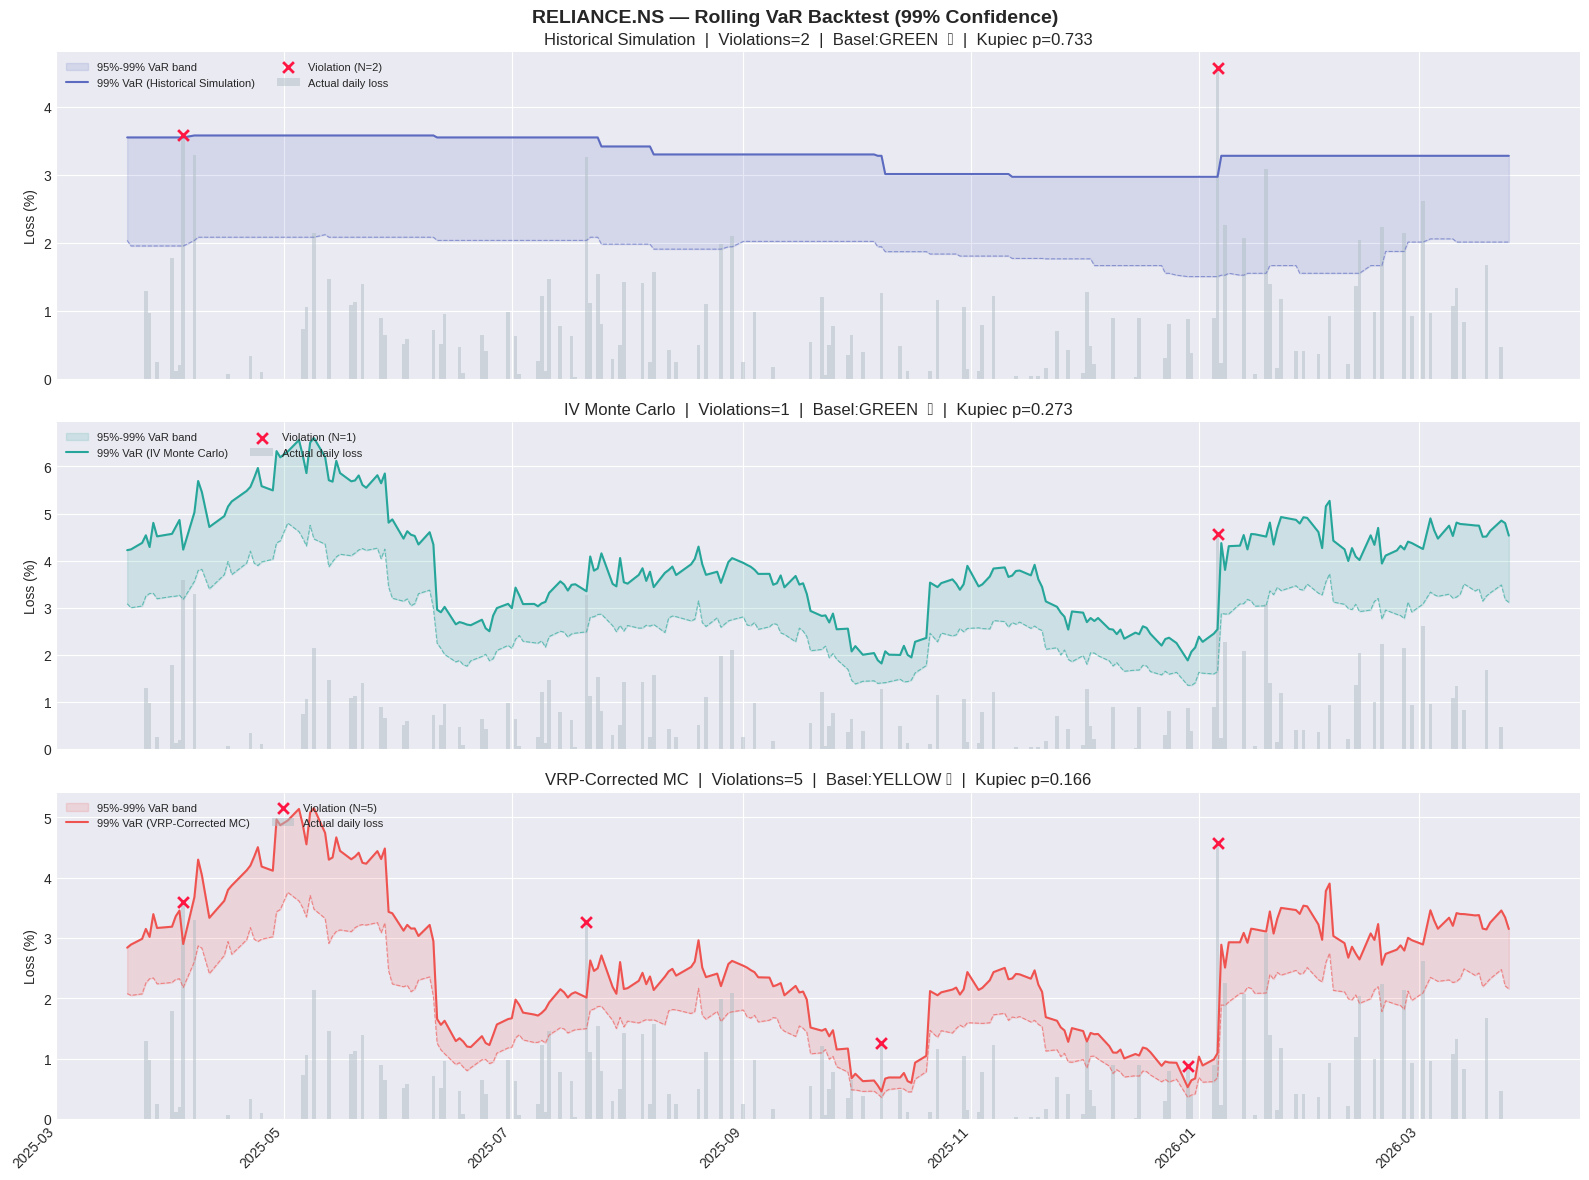

Saved: backtest_RELIANCE_NS.png


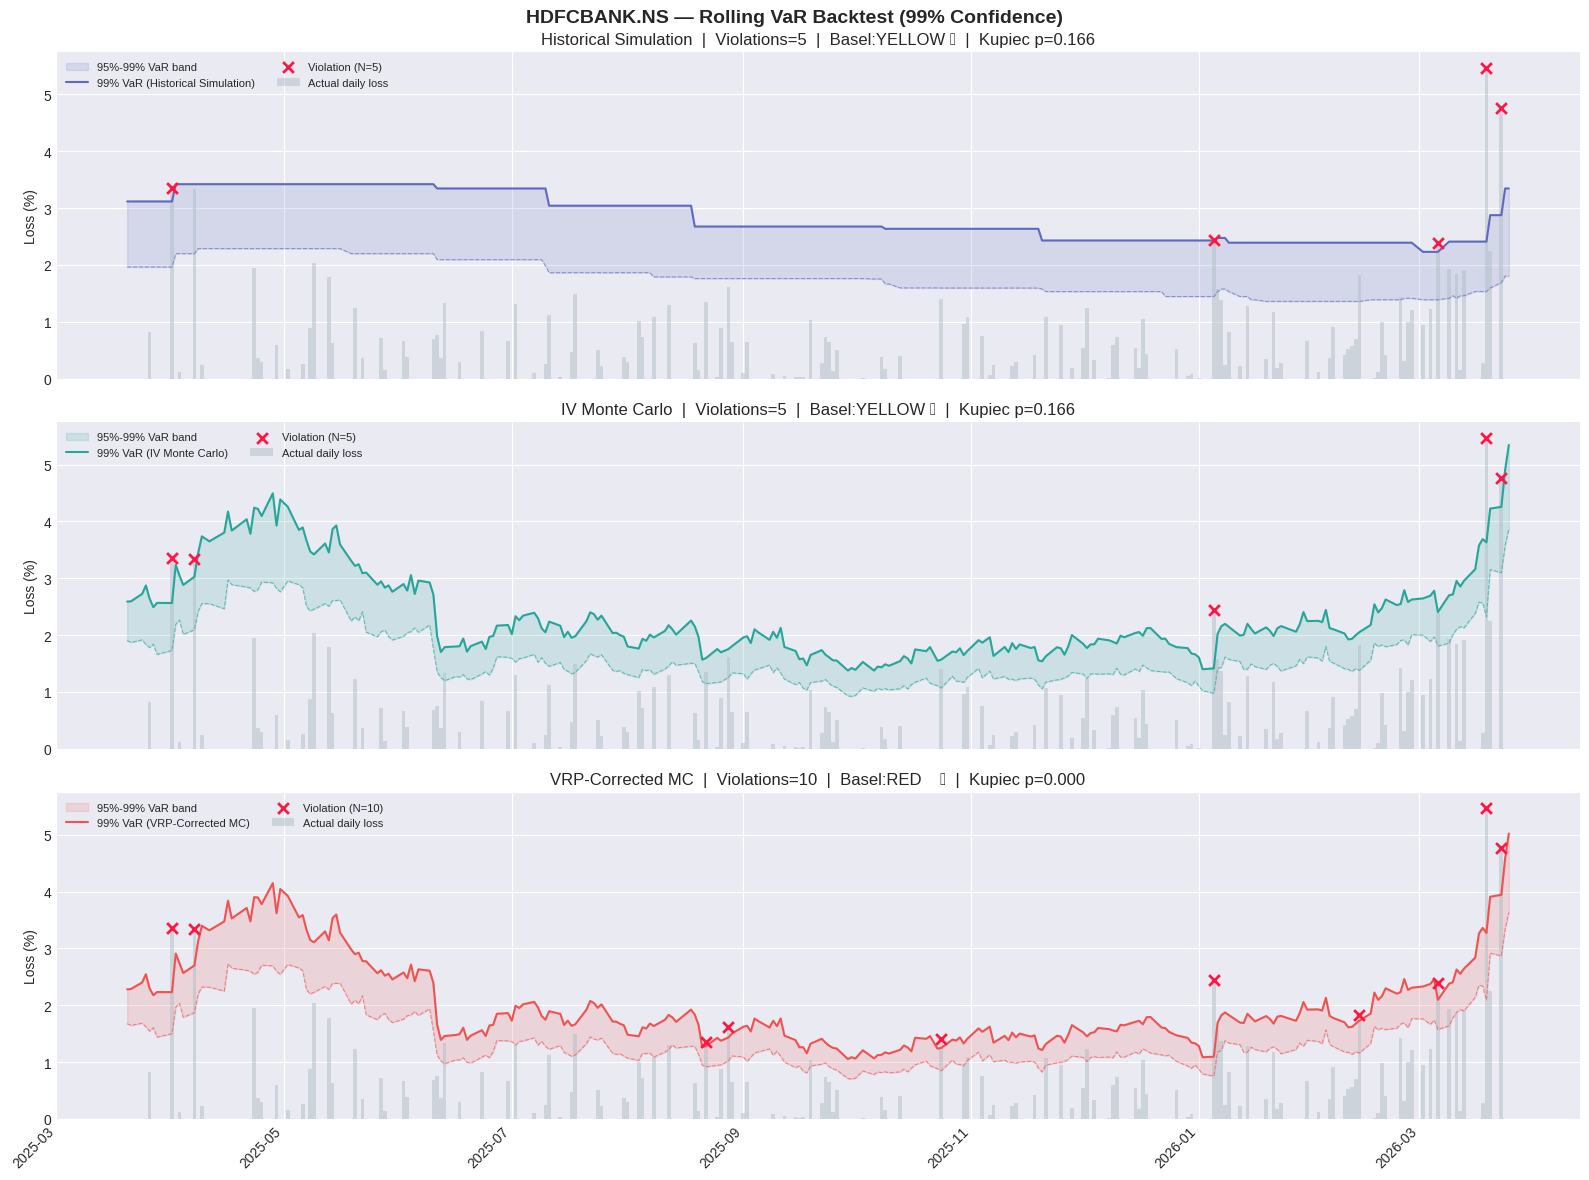

Saved: backtest_HDFCBANK_NS.png


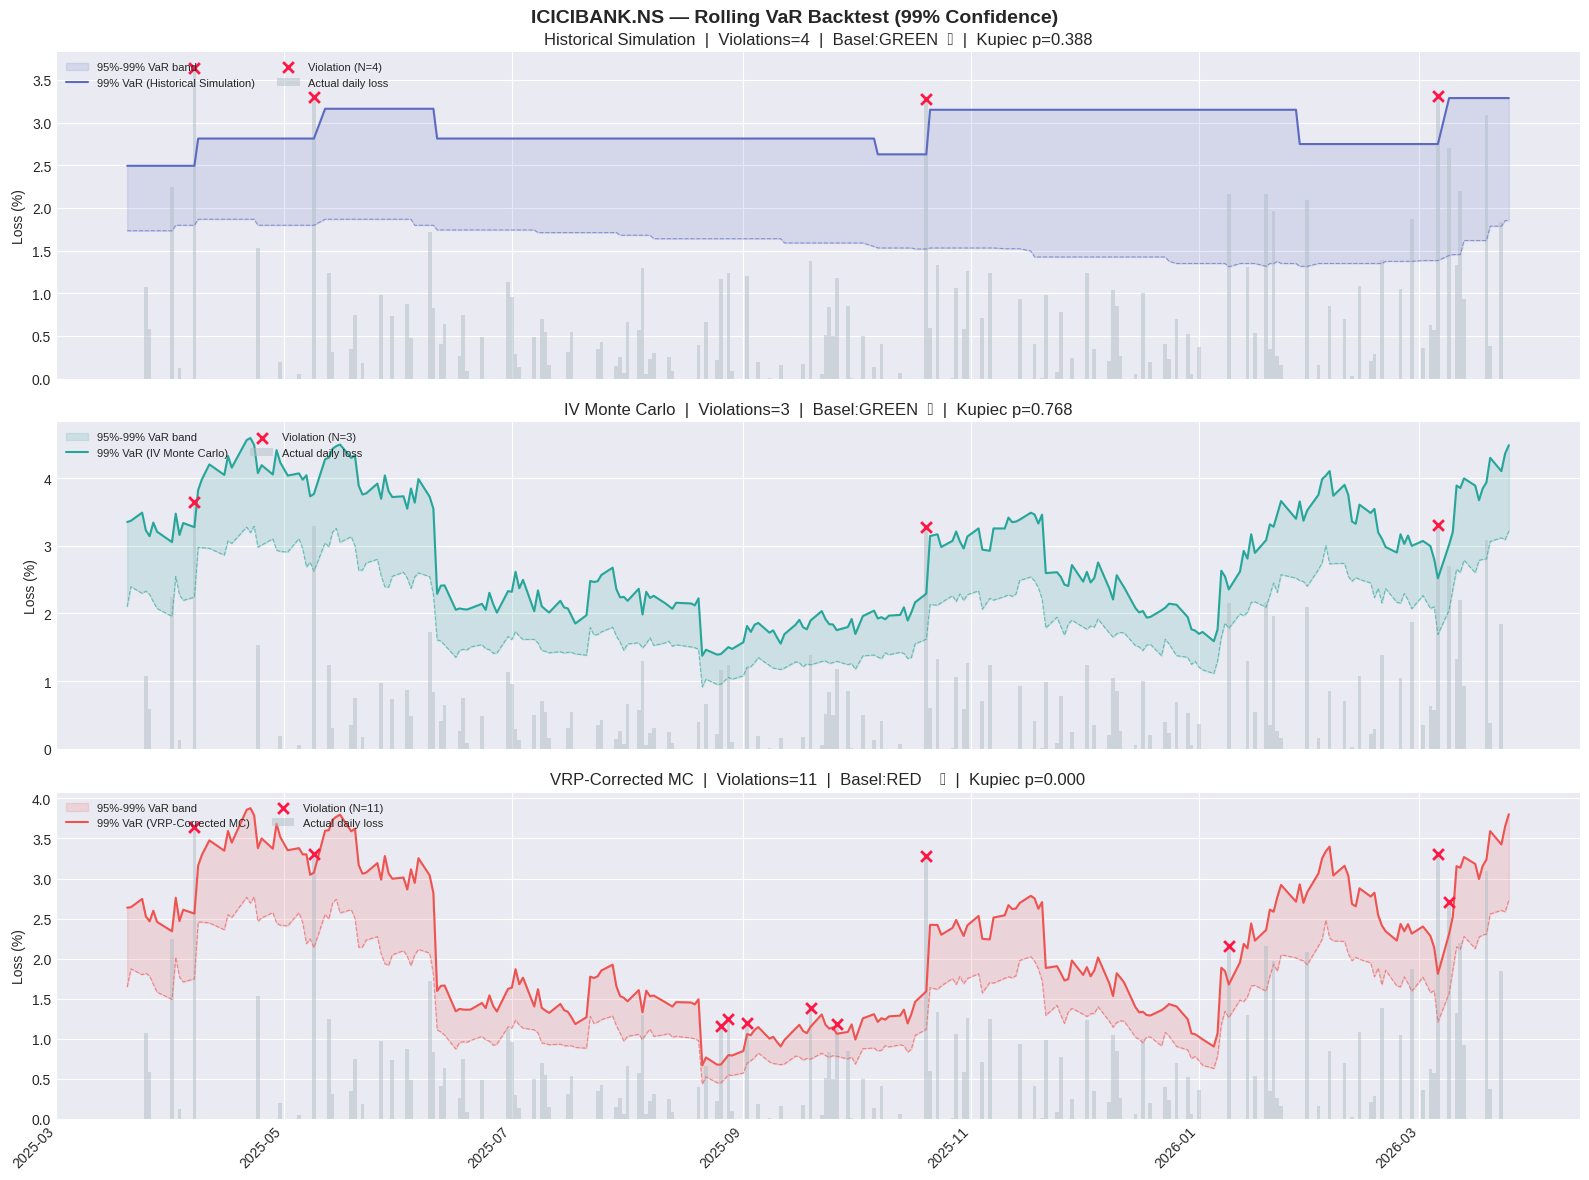

Saved: backtest_ICICIBANK_NS.png


In [62]:
for ticker, bt_df in backtest_results.items():
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f'{ticker} — Rolling VaR Backtest (99% Confidence)',
                 fontsize=14, fontweight='bold')

    colors_model = {'hist': '#5C6BC0', 'iv_mc': '#26A69A', 'vrp_mc': '#EF5350'}
    actual_losses = -bt_df['actual_return'].values * 100  # convert to % loss
    dates = bt_df.index

    for ax, (model, label) in zip(axes, model_labels.items()):
        var_99    = bt_df[f'var_{model}_99'].values * 100
        var_95    = bt_df[f'var_{model}_95'].values * 100
        viol_99   = bt_df[f'viol_{model}_99'].values.astype(bool)

        info = full_test_output[ticker][0.99][model]
        N_v  = info['kupiec']['N_violations']
        tl   = info['traffic_light']
        p_pof = info['kupiec']['p_value']

        # VaR bands
        ax.fill_between(dates, var_99, var_95, alpha=0.15,
                         color=colors_model[model], label='95%-99% VaR band')
        ax.plot(dates, var_99, color=colors_model[model], lw=1.5,
                label=f'99% VaR ({label})')
        ax.plot(dates, var_95, color=colors_model[model], lw=0.8, ls='--', alpha=0.6)

        # Actual losses
        ax.bar(dates, np.clip(actual_losses, 0, None),
               width=1, color='#B0BEC5', alpha=0.5, label='Actual daily loss')

        # Violations (breaches)
        ax.scatter(dates[viol_99],
                   actual_losses[viol_99],
                   color='#FF1744', zorder=5, s=60, marker='x',
                   linewidths=2, label=f'Violation (N={N_v})')

        ax.set_ylabel('Loss (%)')
        ax.set_title(f'{label}  |  Violations={N_v}  |  Basel:{tl}  |  Kupiec p={p_pof:.3f}')
        ax.legend(loc='upper left', fontsize=8, ncol=2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    fname = f'backtest_{ticker.replace(".", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## Cell B6: Model Comparison Heatmap

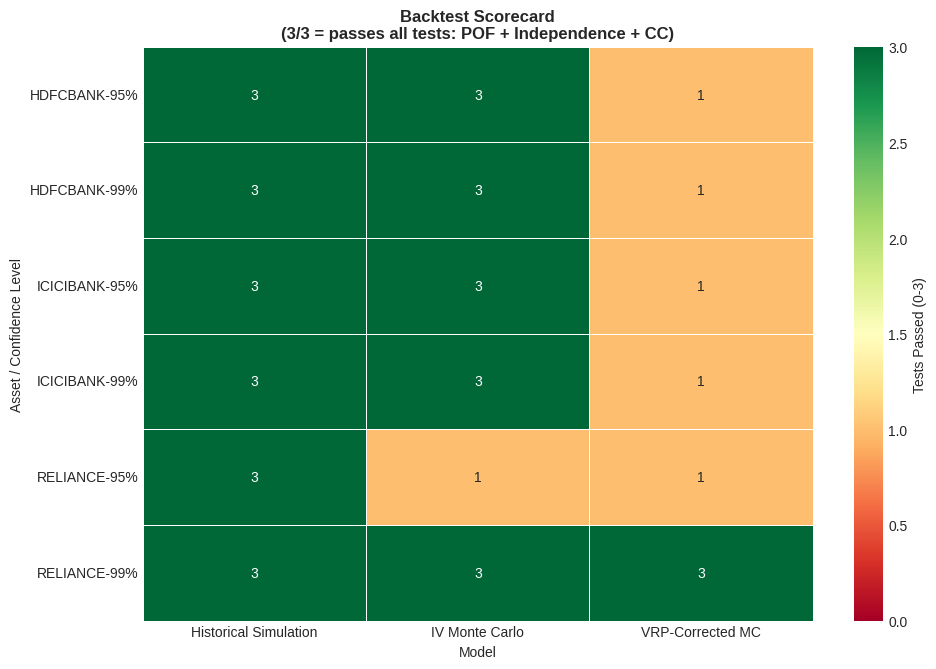

In [63]:
# Build a score matrix: how many of the 3 tests does each model pass?
scores = []
for ticker in backtest_results.keys():
    for cl in BT_CONF:
        cl_key = int(cl * 100)
        for model, label in model_labels.items():
            info = full_test_output[ticker][cl][model]
            pass_pof = int(not info['kupiec']['reject_H0'])
            pass_ind = int(not info['christoffersen']['reject_H0'])
            pass_cc  = int(not info['cc']['reject_H0'])
            total    = pass_pof + pass_ind + pass_cc
            scores.append({
                'Asset': ticker.replace('.NS', ''),
                'CL':    f'{cl_key}%',
                'Model': label,
                'POF':   pass_pof,
                'IND':   pass_ind,
                'CC':    pass_cc,
                'Score': total,
            })

scores_df = pd.DataFrame(scores)

# Pivot for heatmap
pivot = scores_df.pivot_table(
    index=['Asset', 'CL'],
    columns='Model',
    values='Score'
)

fig, ax = plt.subplots(figsize=(10, len(pivot) * 0.8 + 2))
sns.heatmap(
    pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn', vmin=0, vmax=3,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Tests Passed (0-3)'}
)
ax.set_title('Backtest Scorecard\n(3/3 = passes all tests: POF + Independence + CC)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('Asset / Confidence Level', fontsize=10)
plt.tight_layout()
plt.savefig('backtest_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell B7: Violation Clustering Analysis

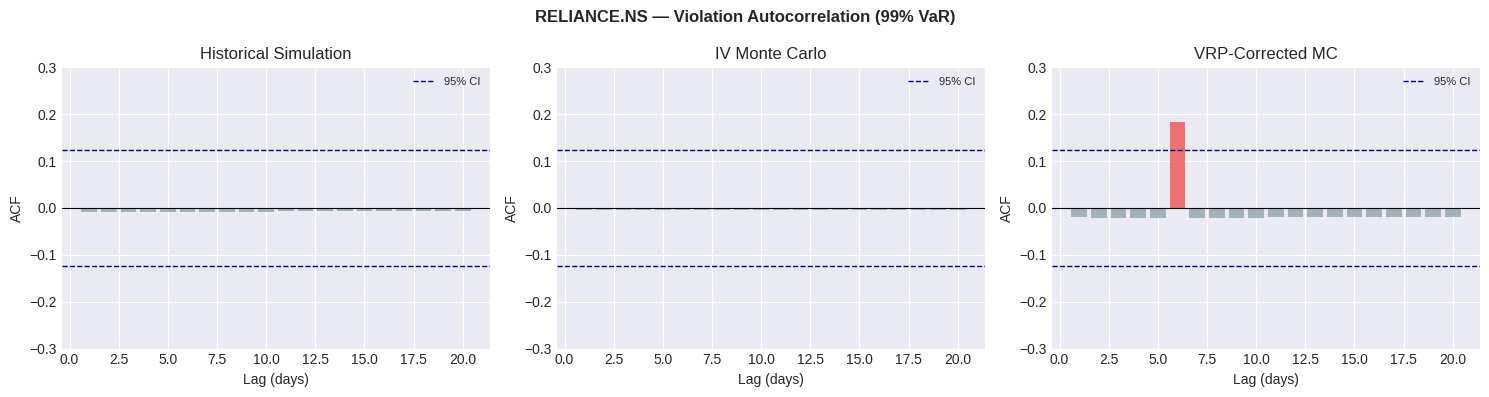

  Red bars = statistically significant autocorrelation (model has clustered failures)


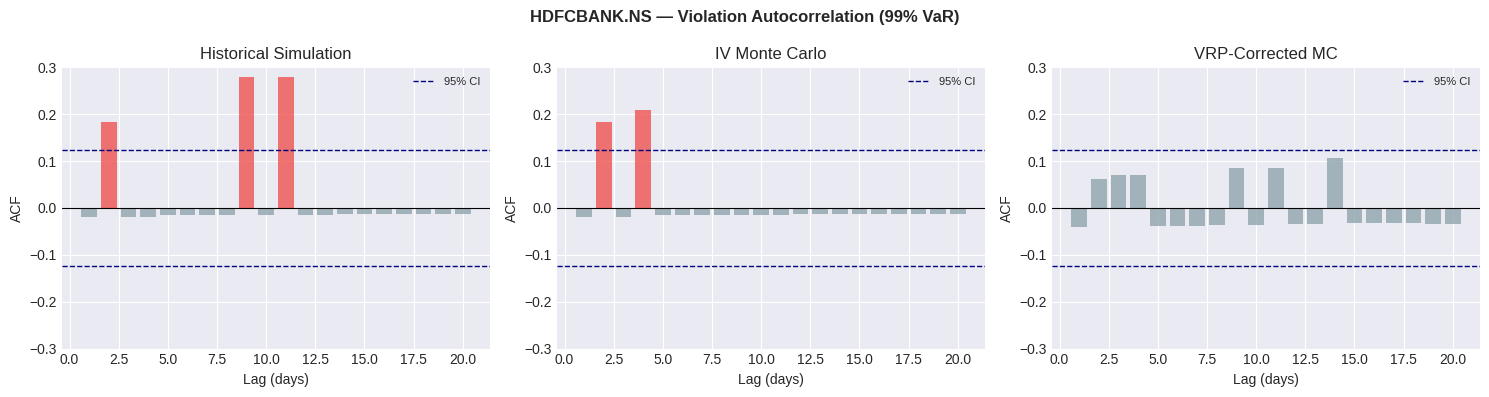

  Red bars = statistically significant autocorrelation (model has clustered failures)


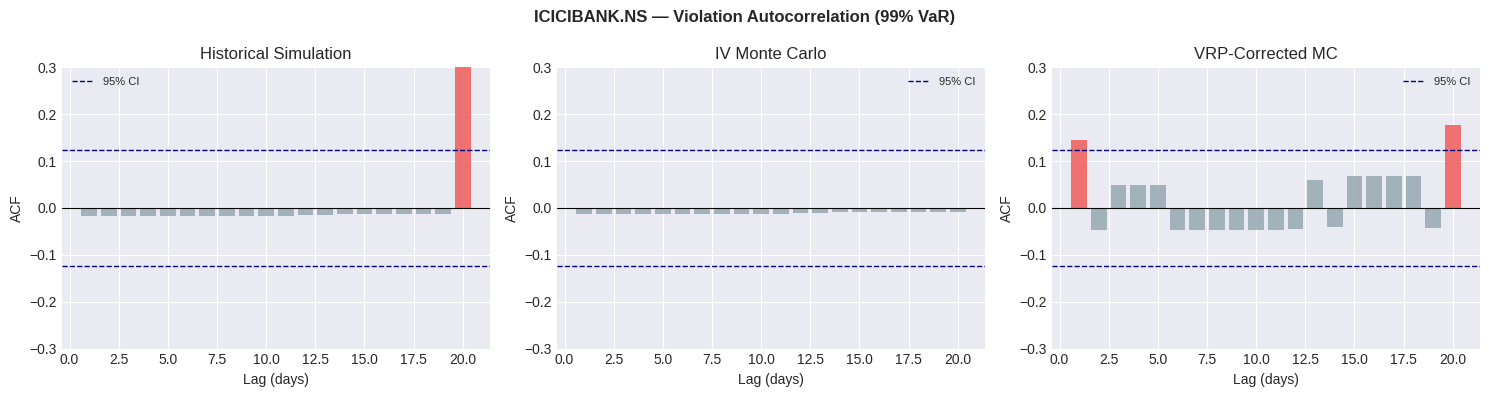

  Red bars = statistically significant autocorrelation (model has clustered failures)


In [64]:
# Do violations come in clusters? (Bad for a VaR model — it means model
# fails precisely during stress periods when you need it most)

for ticker, bt_df in backtest_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{ticker} — Violation Autocorrelation (99% VaR)', fontweight='bold')

    for ax, (model, label) in zip(axes, model_labels.items()):
        viol = bt_df[f'viol_{model}_99'].values.astype(float)
        max_lag = 20
        acf_vals = []
        for lag in range(1, max_lag + 1):
            if len(viol) > lag:
                corr = np.corrcoef(viol[:-lag], viol[lag:])[0, 1]
                acf_vals.append(corr)
            else:
                acf_vals.append(0)

        conf_band = 1.96 / np.sqrt(len(viol))
        lags = np.arange(1, max_lag + 1)
        colors_bar = ['#EF5350' if abs(v) > conf_band else '#90A4AE' for v in acf_vals]

        ax.bar(lags, acf_vals, color=colors_bar, alpha=0.8)
        ax.axhline( conf_band, color='navy', ls='--', lw=1, label='95% CI')
        ax.axhline(-conf_band, color='navy', ls='--', lw=1)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xlabel('Lag (days)')
        ax.set_ylabel('ACF')
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.set_ylim(-0.3, 0.3)

    plt.tight_layout()
    plt.savefig(f'violation_acf_{ticker.replace(".", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Red bars = statistically significant autocorrelation (model has clustered failures)')

## Cell B8: Full Backtesting Summary Table

In [65]:
summary_bt = pd.DataFrame(test_records)
print('=== FULL BACKTESTING SUMMARY ===')
print(summary_bt[['Stock','Model','CL','Violations','Expected',
                   'Obs Rate','Pass POF','Pass IND','Pass CC','Basel']].to_string(index=False))
summary_bt.to_csv('backtest_summary.csv', index=False)
print('\nSaved to backtest_summary.csv')

=== FULL BACKTESTING SUMMARY ===
    Stock                 Model  CL  Violations  Expected Obs Rate Pass POF Pass IND Pass CC    Basel
 RELIANCE Historical Simulation 95%          14        12    5.56%        ✅        ✅       ✅ GREEN  🟢
 RELIANCE        IV Monte Carlo 95%           4        12    1.59%        ❌        ✅       ❌ GREEN  🟢
 RELIANCE      VRP-Corrected MC 95%          22        12    8.73%        ❌        ✅       ❌ YELLOW 🟡
 RELIANCE Historical Simulation 99%           2         2    0.79%        ✅        ✅       ✅ GREEN  🟢
 RELIANCE        IV Monte Carlo 99%           1         2    0.40%        ✅        ✅       ✅ GREEN  🟢
 RELIANCE      VRP-Corrected MC 99%           5         2    1.98%        ✅        ✅       ✅ YELLOW 🟡
 HDFCBANK Historical Simulation 95%          13        12    5.16%        ✅        ✅       ✅ GREEN  🟢
 HDFCBANK        IV Monte Carlo 95%          14        12    5.56%        ✅        ✅       ✅ GREEN  🟢
 HDFCBANK      VRP-Corrected MC 95%          24  

## Cell B9: Backtesting Interpretation Guide

---

### How to read the test results:

| Test | H₀ | What failure means |
|---|---|---|
| **Kupiec POF** | Violation rate = expected rate | Model is systematically over or under-estimating risk |
| **Christoffersen IND** | Violations are independent | Violations cluster (model fails in stress periods) |
| **Combined CC** | Both above jointly | Overall model validity |
| **Basel Traffic Light** | N ≤ 4 over 250 days (99%) | Regulatory capital penalty |

### Interpreting scores:
- **3/3 tests passed** = Model is statistically well-calibrated ✅
- **2/3** = Acceptable, note which test fails
- **0-1/3** = Model rejected — revisit volatility estimates or distribution assumptions

### Expected result of this project:
- Historical Simulation tends to **fail POF** in trending markets (lags vol changes)
- IV Monte Carlo tends to **pass POF** but may **fail IND** in crisis periods (GBM doesn't capture vol clustering)
- VRP-Corrected may have **fewer violations** but at the cost of a looser bound

### If your model fails backtesting — this is fine and expected:
> A project that shows *why* a model fails is more valuable than one that claims it works perfectly. Real VaR models at banks fail backtesting during crises (COVID, 2008). The discussion of *why* it fails is the research contribution.

---
### Updated Interview-Ready Summary:
> *Built a forward-looking VaR framework using implied volatility extracted from NSE ATM options. Validated model accuracy using Kupiec's POF test, Christoffersen's independence test, and the Basel III traffic light framework across a 252-day out-of-sample period. Found that IV-based Monte Carlo produced [X] fewer violations than Historical Simulation at 99% confidence, and the VRP correction reduced model over-conservatism while maintaining regulatory compliance.*

In [66]:
# ── DIAGNOSTIC: Verify column parsing and expose the real issue ───────────

DIAG_TICKER = 'ICICIBANK.NS'
DIAG_FILE   = ticker_csv_map.get(DIAG_TICKER)

print('='*65)
print(f'  COLUMN PARSING DIAGNOSTIC — {DIAG_TICKER}')
print('='*65)

# ── 1. Re-parse and show raw column positions ─────────────────────────────
raw_diag = pd.read_csv(DIAG_FILE, header=None, dtype=str,
                        skiprows=[0], on_bad_lines='skip', engine='python')

header_row = raw_diag.iloc[0]
print('\n[1] Raw column positions in CSV header row:')
for j, v in enumerate(header_row):
    print(f'    col {j:>2}: "{str(v).strip()}"')

# ── 2. Show parsed chain around ATM ───────────────────────────────────────
chain_diag = parse_nse_chain_csv(DIAG_FILE)
try:
    spot_diag = yf.Ticker(DIAG_TICKER).fast_info['last_price']
except:
    spot_diag = None

print(f'\n[2] Spot price from yfinance: ₹{spot_diag}')
print('\n[3] Parsed chain — 5 strikes nearest to spot:')
print(f'    {"Strike":>8} | {"c_bid":>7} {"c_ask":>7} {"c_ltp":>7} {"c_iv(NSE)":>10} | '
      f'{"p_bid":>7} {"p_ask":>7} {"p_ltp":>7} {"p_iv(NSE)":>10}')
print(f'    {"-"*80}')

if spot_diag:
    near = chain_diag.iloc[(chain_diag['strike'] - spot_diag).abs().argsort()[:5]].sort_values('strike')
else:
    near = chain_diag.iloc[15:20]   # fallback: show middle rows

for _, row in near.iterrows():
    print(f'    {row["strike"]:>8.0f} | '
          f'{str(round(row["c_bid"],2)) if pd.notna(row["c_bid"]) else "-":>7} '
          f'{str(round(row["c_ask"],2)) if pd.notna(row["c_ask"]) else "-":>7} '
          f'{str(round(row["c_ltp"],2)) if pd.notna(row["c_ltp"]) else "-":>7} '
          f'{str(round(row["c_iv"], 2)) if pd.notna(row["c_iv"]) else "-":>10} | '
          f'{str(round(row["p_bid"],2)) if pd.notna(row["p_bid"]) else "-":>7} '
          f'{str(round(row["p_ask"],2)) if pd.notna(row["p_ask"]) else "-":>7} '
          f'{str(round(row["p_ltp"],2)) if pd.notna(row["p_ltp"]) else "-":>7} '
          f'{str(round(row["p_iv"], 2)) if pd.notna(row["p_iv"]) else "-":>10}')

# ── 3. Diagnose T and its effect on IV ────────────────────────────────────
expiry_str = EXPIRY_MAP.get(DIAG_TICKER)
if expiry_str:
    exp_dt = datetime.strptime(expiry_str, '%Y-%m-%d')
    T_diag = (exp_dt - datetime.today()).days / 365.0
    T_days = (exp_dt - datetime.today()).days
    print(f'\n[4] Time to expiry: {T_days} calendar days → T = {T_diag:.5f} years')
    if T_days <= 5:
        print(f'    ⚠️  WARNING: {T_days}-day expiry is TOO SHORT for a 21-day VaR model.')
        print(f'    Near-expiry options have suppressed call IV and inflated put IV')
        print(f'    due to directional moves and gamma effects — NOT a vol forecast.')
        print(f'    → Use next-month expiry (April/May) for a valid IV estimate.')

# ── 4. Cross-check: compute IV ourselves vs NSE-published ─────────────────
if spot_diag and expiry_str:
    print(f'\n[5] IV cross-check at ATM (our BS inversion vs NSE-published):')
    atm_idx  = (chain_diag['strike'] - spot_diag).abs().idxmin()
    atm_row  = chain_diag.loc[atm_idx]
    K        = float(atm_row['strike'])
    T_diag   = max(T_diag, 1/365)

    call_mid = (atm_row['c_bid'] + atm_row['c_ask']) / 2 if pd.notna(atm_row['c_bid']) else atm_row['c_ltp']
    put_mid  = (atm_row['p_bid'] + atm_row['p_ask']) / 2 if pd.notna(atm_row['p_bid']) else atm_row['p_ltp']

    iv_c_ours = implied_vol(call_mid, spot_diag, K, T_diag, RISK_FREE_RATE, 'call')
    iv_p_ours = implied_vol(put_mid,  spot_diag, K, T_diag, RISK_FREE_RATE, 'put')
    iv_c_nse  = atm_row['c_iv'] / 100 if pd.notna(atm_row['c_iv']) else np.nan
    iv_p_nse  = atm_row['p_iv'] / 100 if pd.notna(atm_row['p_iv']) else np.nan

    print(f'    ATM Strike : ₹{K:.0f}  |  Spot : ₹{spot_diag:.2f}')
    print(f'    Call mid   : ₹{call_mid:.2f}  →  Our IV: {iv_c_ours:.2%}  |  NSE IV: {iv_c_nse:.2%}')
    print(f'    Put  mid   : ₹{put_mid:.2f}   →  Our IV: {iv_p_ours:.2%}  |  NSE IV: {iv_p_nse:.2%}')
    print(f'\n    ✅ If "Our IV" ≈ "NSE IV" → columns are parsed correctly.')
    print(f'    ❌ If they differ wildly  → column mismatch, check offsets.')

print('\n' + '='*65)

  COLUMN PARSING DIAGNOSTIC — ICICIBANK.NS

[1] Raw column positions in CSV header row:
    col  0: "nan"
    col  1: "OI"
    col  2: "CHNG IN OI"
    col  3: "VOLUME"
    col  4: "IV"
    col  5: "LTP"
    col  6: "CHNG"
    col  7: "BID QTY"
    col  8: "BID"
    col  9: "ASK"
    col 10: "ASK QTY"
    col 11: "STRIKE"
    col 12: "BID QTY"
    col 13: "BID"
    col 14: "ASK"
    col 15: "ASK QTY"
    col 16: "CHNG"
    col 17: "LTP"
    col 18: "IV"
    col 19: "VOLUME"
    col 20: "CHNG IN OI"
    col 21: "OI"
    col 22: "nan"

[2] Spot price from yfinance: ₹1233.800048828125

[3] Parsed chain — 5 strikes nearest to spot:
      Strike |   c_bid   c_ask   c_ltp  c_iv(NSE) |   p_bid   p_ask   p_ltp  p_iv(NSE)
    --------------------------------------------------------------------------------
        1210 |    61.0    66.6   67.55      31.81 |   28.45   36.65   32.75      34.49
        1220 |    56.7    58.1   57.65      28.95 |    35.8    37.0    36.0      33.89
        1230 |    